# Performance Evaluation of Federated Learning Algorithms under IID and Non-IID Data Distributions   

# A Comprehensive Empirical Evaluation of Federated Learning Algorithms under Data Heterogeneity

**Author:** Sahib Zada Zohaib Ali Shah | **ID:** g202531010  
**Supervisor:** Dr. Ayaz Khan | **Course:** Distributed Computing

---
## Section 1 — Environment Setup & Reproducibility

In [1]:
# ═══════════════════════════════════════════════════
# Section 1 · Setup
# ═══════════════════════════════════════════════════
import os
import sys
import copy
import time
import random
import logging
import warnings
import itertools
import subprocess
import importlib

from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple, Any
from pathlib import Path

def _pip(*pkgs):
    """Install missing packages only when running interactively."""
    for pkg in pkgs:
        mod = pkg.split("==")[0].replace("-", "_")
        if importlib.util.find_spec(mod) is None:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Optional notebook convenience
_pip("scipy", "matplotlib", "seaborn", "pandas")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

# warnings.filterwarnings("ignore")  # Avoid hiding useful debugging information

# ── Platform ─────────────────────────────────────────
def detect_platform():
    if "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
        return "kaggle"
    try:
        import google.colab
        return "colab"
    except ImportError:
        return "local"

PLATFORM = detect_platform()

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    GPU_NAME = torch.cuda.get_device_name(0)
    N_GPU = torch.cuda.device_count()
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    GPU_NAME = "Apple MPS"
    N_GPU = 1
else:
    DEVICE = torch.device("cpu")
    GPU_NAME = "None"
    N_GPU = 0

# ── Seed ─────────────────────────────────────────────
MASTER_SEED = 42

def set_seed(seed: int = MASTER_SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()

# ── Logger ───────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger("FL")

# ── Directories ──────────────────────────────────────
RESULTS_DIR = Path("./fl_results")
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

for d in [RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Plot style ───────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
    "lines.markersize": 5,
})

ALGO_COLORS = {
    "FedAvg": "#2196F3",
    "FedProx": "#FF5722",
    "SCAFFOLD": "#4CAF50",
    "FedNova": "#9C27B0",
}

ALGO_MARKERS = {
    "FedAvg": "o",
    "FedProx": "s",
    "SCAFFOLD": "^",
    "FedNova": "D",
}

logger.info(f"Platform={PLATFORM.upper()} | Device={DEVICE} | GPUs={N_GPU} ({GPU_NAME})")
logger.info(f"PyTorch={torch.__version__} | Seed={MASTER_SEED}")

19:10:28 [INFO] Platform=LOCAL | Device=mps | GPUs=1 (Apple MPS)
19:10:28 [INFO] PyTorch=2.8.0 | Seed=42


---
## Section 2 — Configuration

All hyperparameters in one place. **Only edit values here.**

In [2]:
# ═══════════════════════════════════════════════════
# Section 2 · Configuration
# ═══════════════════════════════════════════════════

from dataclasses import dataclass, field
from typing import List


@dataclass
class FLConfig:
    # ── Reproducibility ─────────────────────────────
    seeds: List[int] = field(default_factory=lambda: [42, 52, 62])

    # ── Federation ──────────────────────────────────
    num_clients: int = 5
    num_rounds: int = 50
    client_fraction: float = 0.6   # partial participation

    # ── Local training ──────────────────────────────
    local_epochs: int = 1
    batch_size: int = 64
    lr: float = 0.01
    momentum: float = 0.9
    weight_decay: float = 1e-4

    # ── Algorithm-specific ──────────────────────────
    mu: float = 0.01   # FedProx proximal coefficient

    # ── Data heterogeneity ──────────────────────────
    labels_per_client: int = 2
    dirichlet_alpha: float = 0.5

    # ── Sweep values ────────────────────────────────
    mu_values: List[float] = field(default_factory=lambda: [0.001, 0.01, 0.1])
    epoch_values: List[int] = field(default_factory=lambda: [1, 3, 5])
    alpha_values: List[float] = field(default_factory=lambda: [0.1, 0.5, 1.0])

    # ── Evaluation ──────────────────────────────────
    eval_every: int = 5

    def __post_init__(self):
        if not self.seeds:
            raise ValueError("seeds must contain at least one value")
        if self.num_clients <= 0:
            raise ValueError("num_clients must be > 0")
        if self.num_rounds <= 0:
            raise ValueError("num_rounds must be > 0")
        if not (0 < self.client_fraction <= 1):
            raise ValueError("client_fraction must be in (0, 1]")
        if self.local_epochs <= 0:
            raise ValueError("local_epochs must be > 0")
        if self.batch_size <= 0:
            raise ValueError("batch_size must be > 0")
        if self.lr <= 0:
            raise ValueError("lr must be > 0")
        if self.momentum < 0:
            raise ValueError("momentum must be >= 0")
        if self.weight_decay < 0:
            raise ValueError("weight_decay must be >= 0")
        if self.mu < 0:
            raise ValueError("mu must be >= 0")
        if self.labels_per_client <= 0:
            raise ValueError("labels_per_client must be > 0")
        if self.dirichlet_alpha <= 0:
            raise ValueError("dirichlet_alpha must be > 0")
        if self.eval_every <= 0:
            raise ValueError("eval_every must be > 0")

        if any(v < 0 for v in self.mu_values):
            raise ValueError("all mu_values must be >= 0")
        if any(v <= 0 for v in self.epoch_values):
            raise ValueError("all epoch_values must be > 0")
        if any(v <= 0 for v in self.alpha_values):
            raise ValueError("all alpha_values must be > 0")

    @property
    def algorithms(self) -> List[str]:
        return ["FedAvg", "FedProx", "SCAFFOLD", "FedNova"]


CFG = FLConfig()

# ── Print configuration summary ─────────────────────
print("=" * 56)
print("  Federated Learning — Configuration")
print("=" * 56)
for k in [
    "num_rounds",
    "num_clients",
    "client_fraction",
    "local_epochs",
    "batch_size",
    "lr",
    "mu",
    "seeds",
    "eval_every",
]:
    print(f"  {k:<22} : {getattr(CFG, k)}")
print(f"  {'algorithms':<22} : {CFG.algorithms}")
print("=" * 56)

# ── Estimate total work ─────────────────────────────
# Assumptions:
# Exp1: all algorithms × 2 datasets × 2 distributions × all seeds × all rounds
# Exp2: all algorithms × all Dirichlet alpha values × all seeds × all rounds
# Exp3a: FedProx mu sweep × all seeds × all rounds
# Exp3b: local epoch sweep × all seeds × all rounds

exp1_rounds = len(CFG.algorithms) * 2 * 2 * len(CFG.seeds) * CFG.num_rounds
exp2_rounds = len(CFG.algorithms) * len(CFG.alpha_values) * len(CFG.seeds) * CFG.num_rounds
exp3a_rounds = len(CFG.mu_values) * len(CFG.seeds) * CFG.num_rounds
exp3b_rounds = len(CFG.epoch_values) * len(CFG.seeds) * CFG.num_rounds

total_rounds = exp1_rounds + exp2_rounds + exp3a_rounds + exp3b_rounds

print(f"\nEstimated total training rounds : {total_rounds:,}")
print(f"  Exp1 baseline                : {exp1_rounds:,}")
print(f"  Exp2 Dirichlet sweep         : {exp2_rounds:,}")
print(f"  Exp3a FedProx mu sweep       : {exp3a_rounds:,}")
print(f"  Exp3b local epoch sweep      : {exp3b_rounds:,}")

print(f"\nApproximate runtime:")
print(f"  GPU (~0.3 s/round)           : {total_rounds * 0.3 / 60:.0f} min")
print(f"  CPU (~2.0 s/round)           : {total_rounds * 2 / 3600:.1f} hrs")

  Federated Learning — Configuration
  num_rounds             : 50
  num_clients            : 5
  client_fraction        : 0.6
  local_epochs           : 1
  batch_size             : 64
  lr                     : 0.01
  mu                     : 0.01
  seeds                  : [42, 52, 62]
  eval_every             : 5
  algorithms             : ['FedAvg', 'FedProx', 'SCAFFOLD', 'FedNova']

Estimated total training rounds : 5,100
  Exp1 baseline                : 2,400
  Exp2 Dirichlet sweep         : 1,800
  Exp3a FedProx mu sweep       : 450
  Exp3b local epoch sweep      : 450

Approximate runtime:
  GPU (~0.3 s/round)           : 26 min
  CPU (~2.0 s/round)           : 2.8 hrs


---
## Section 3 — Dataset Loading

MNIST    | train=60,000 | test=10,000 | shape=(1, 28, 28)
CIFAR-10 | train=50,000 | test=10,000 | shape=(3, 32, 32)


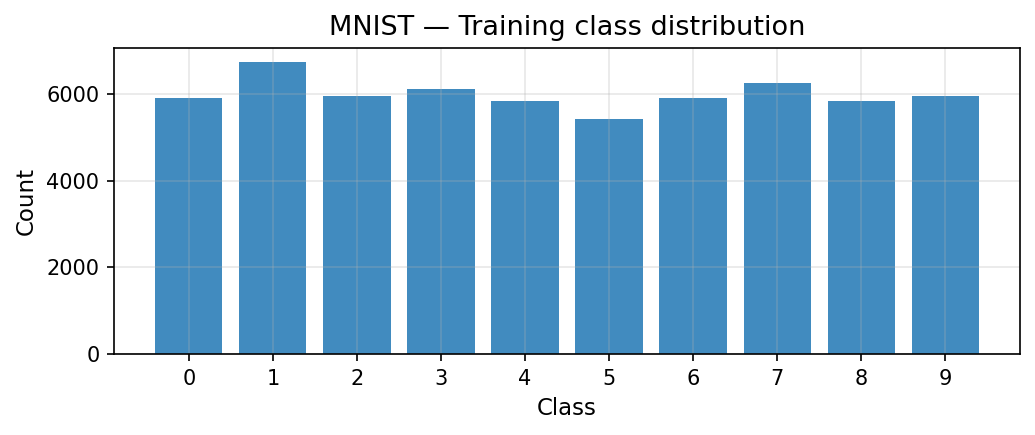

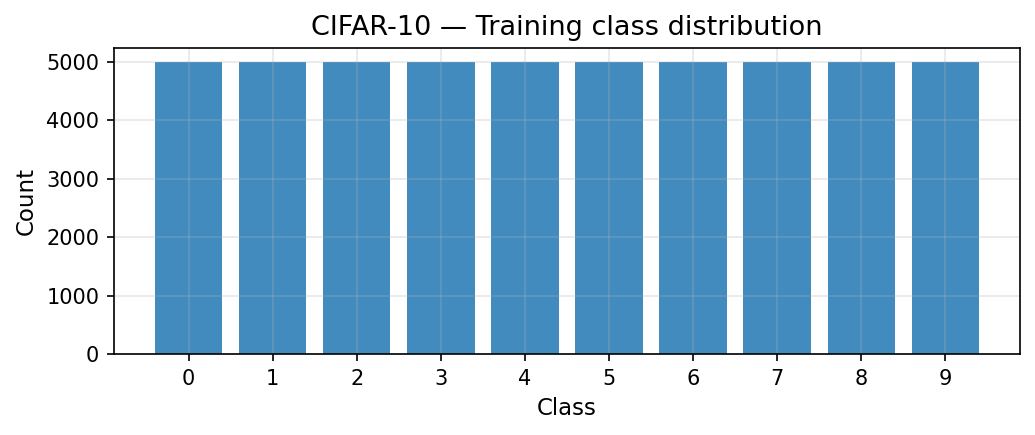

In [3]:
# ═══════════════════════════════════════════════════
# Section 3 · Datasets
# ═══════════════════════════════════════════════════

DATA_ROOT = Path("./data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

TRANSFORMS = {
    "mnist": transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ]),
    "cifar10": transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ]),
}


def load_dataset(name: str) -> Tuple[Dataset, Dataset, int, int]:
    """
    Load a dataset and return:
    (train_dataset, test_dataset, num_classes, in_channels)
    """
    name = name.lower().strip()

    if name not in TRANSFORMS:
        raise ValueError(f"Unknown dataset '{name}'. Choose from {list(TRANSFORMS.keys())}")

    tf = TRANSFORMS[name]

    if name == "mnist":
        train_ds = datasets.MNIST(
            root=DATA_ROOT,
            train=True,
            download=True,
            transform=tf
        )
        test_ds = datasets.MNIST(
            root=DATA_ROOT,
            train=False,
            download=True,
            transform=tf
        )
        return train_ds, test_ds, 10, 1

    if name == "cifar10":
        train_ds = datasets.CIFAR10(
            root=DATA_ROOT,
            train=True,
            download=True,
            transform=tf
        )
        test_ds = datasets.CIFAR10(
            root=DATA_ROOT,
            train=False,
            download=True,
            transform=tf
        )
        return train_ds, test_ds, 10, 3

    raise ValueError(f"Unhandled dataset '{name}'")


def get_targets(dataset: Dataset) -> np.ndarray:
    """
    Safely extract integer labels from torchvision Dataset or Subset.
    """
    if isinstance(dataset, Subset):
        base_targets = get_targets(dataset.dataset)
        return base_targets[np.asarray(dataset.indices, dtype=int)]

    if hasattr(dataset, "targets"):
        targets = dataset.targets
    elif hasattr(dataset, "labels"):
        targets = dataset.labels
    else:
        raise AttributeError("Dataset does not provide 'targets' or 'labels'")

    if isinstance(targets, torch.Tensor):
        return targets.cpu().numpy().astype(int)

    return np.asarray(targets, dtype=int)


# ── Preload datasets once and reuse everywhere ──────────────────────────────
train_mnist, test_mnist, N_CLS_MNIST, IN_CH_MNIST = load_dataset("mnist")
train_cifar, test_cifar, N_CLS_CIFAR, IN_CH_CIFAR = load_dataset("cifar10")

for name, train_ds, test_ds in [
    ("MNIST", train_mnist, test_mnist),
    ("CIFAR-10", train_cifar, test_cifar),
]:
    img, _ = train_ds[0]
    print(
        f"{name:8s} | train={len(train_ds):,} | test={len(test_ds):,} "
        f"| shape={tuple(img.shape)}"
    )


# ── Dataset distribution plots ──────────────────────────────────────────────
def plot_class_distribution(dataset: Dataset, dataset_name: str, num_classes: int = 10):
    counts = np.bincount(get_targets(dataset), minlength=num_classes)

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(range(num_classes), counts, alpha=0.85)
    ax.set_title(f"{dataset_name} — Training class distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_xticks(range(num_classes))

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f"{dataset_name.lower().replace('-', '_')}_distribution.png",
                bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_class_distribution(train_mnist, "MNIST", num_classes=N_CLS_MNIST)
plot_class_distribution(train_cifar, "CIFAR-10", num_classes=N_CLS_CIFAR)

---
## Section 4 — Data Partitioning

| Strategy | Parameter | Effect |
|----------|-----------|--------|
| IID | — | Uniform random split (baseline) |
| Label-skew | `labels_per_client` | Each client holds only K classes |
| Dirichlet | `α` | Class proportions ∼ Dir(α); lower α = more heterogeneous |

EMD (Earth Mover's Distance) quantifies heterogeneity numerically.


iid          | EMD=0.0594 | sizes=[12000, 12000, 12000, 12000, 12000]


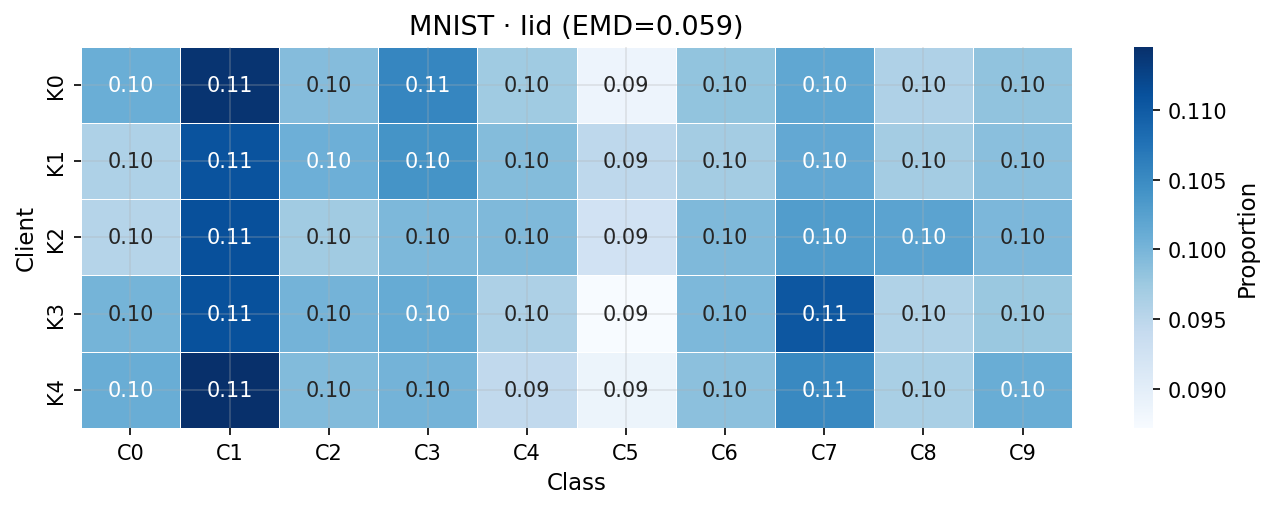

label_skew   | EMD=1.9384 | sizes=[11876, 12163, 11686, 11370, 11760]


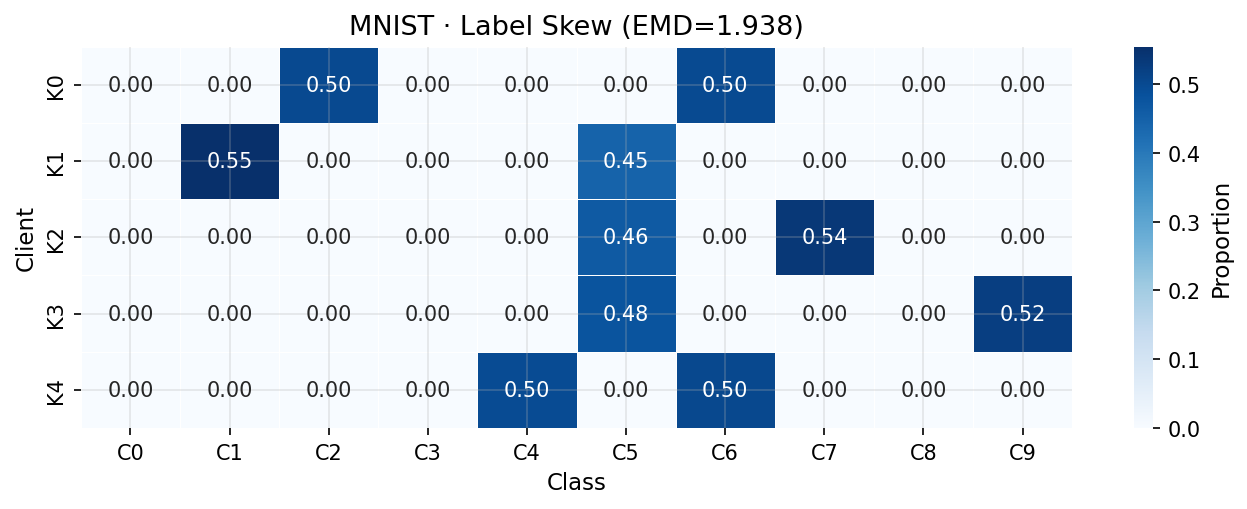

dirichlet    | EMD=0.6401 | sizes=[12862, 9260, 14702, 10175, 13001]


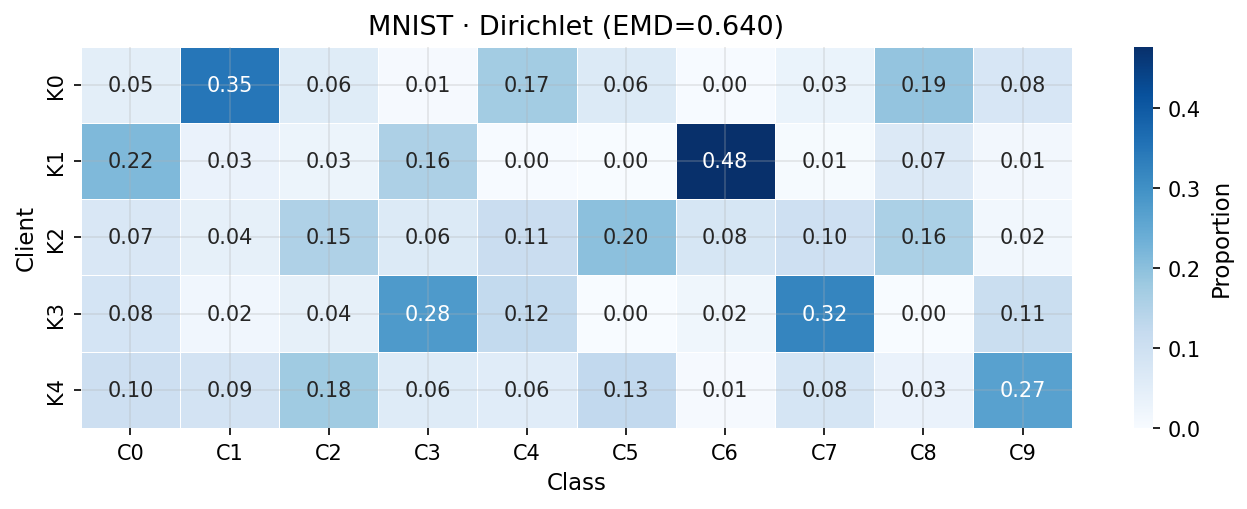

In [4]:
# ═══════════════════════════════════════════════════
# Section 4 · Partitioning
# ═══════════════════════════════════════════════════

def _class_map(targets: np.ndarray, n_cls: int) -> Dict[int, List[int]]:
    return {c: np.where(targets == c)[0].tolist() for c in range(n_cls)}


def partition_iid(dataset, num_clients, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(dataset))
    rng.shuffle(idx)

    splits = np.array_split(idx, num_clients)
    return {k: Subset(dataset, s.tolist()) for k, s in enumerate(splits)}


def partition_label_skew(dataset, num_clients, labels_per_client, n_cls, seed=42):
    rng = np.random.default_rng(seed)
    targets = get_targets(dataset)
    cls_map = _class_map(targets, n_cls)

    # Shuffle class indices once
    for c in range(n_cls):
        rng.shuffle(cls_map[c])

    # Assign specific labels to each client
    label_assignments = []
    all_labels = np.arange(n_cls)

    for k in range(num_clients):
        assigned = rng.choice(all_labels, size=labels_per_client, replace=False)
        label_assignments.append(assigned)

    out: Dict[int, List[int]] = {k: [] for k in range(num_clients)}

    for k in range(num_clients):
        for lbl in label_assignments[k]:
            out[k].extend(cls_map[lbl])

    return {k: Subset(dataset, v) for k, v in out.items()}


def partition_dirichlet(dataset, num_clients, alpha, n_cls, seed=42):
    rng = np.random.default_rng(seed)
    targets = get_targets(dataset)
    cls_map = _class_map(targets, n_cls)

    # Shuffle class indices
    for c in range(n_cls):
        rng.shuffle(cls_map[c])

    out: Dict[int, List[int]] = {k: [] for k in range(num_clients)}

    for c in range(n_cls):
        proportions = rng.dirichlet(alpha * np.ones(num_clients))

        # Avoid numerical issues
        proportions = np.maximum(proportions, 1e-6)
        proportions /= proportions.sum()

        splits = (np.cumsum(proportions) * len(cls_map[c])).astype(int)[:-1]
        class_chunks = np.split(cls_map[c], splits)

        for k, chunk in enumerate(class_chunks):
            out[k].extend(chunk.tolist())

    return {k: Subset(dataset, v) for k, v in out.items()}


def build_client_datasets(dataset, split_type, num_clients, n_cls,
                          seed=42, labels_per_client=2, dirichlet_alpha=0.5):

    split_type = split_type.lower()

    if split_type == "iid":
        return partition_iid(dataset, num_clients, seed)

    elif split_type == "label_skew":
        return partition_label_skew(
            dataset, num_clients, labels_per_client, n_cls, seed
        )

    elif split_type == "dirichlet":
        return partition_dirichlet(
            dataset, num_clients, dirichlet_alpha, n_cls, seed
        )

    raise ValueError(f"Unknown split: {split_type}")


def compute_emd(client_datasets, n_cls) -> float:
    """
    Compute average Earth Mover’s Distance (Wasserstein distance)
    between client distributions and uniform distribution.
    """
    uniform = np.ones(n_cls) / n_cls
    emds = []

    for sub in client_datasets.values():
        counts = np.bincount(get_targets(sub), minlength=n_cls).astype(float)

        if counts.sum() == 0:
            continue

        probs = counts / counts.sum()

        emd = stats.wasserstein_distance(
            np.arange(n_cls), np.arange(n_cls), probs, uniform
        )
        emds.append(emd)

    return float(np.mean(emds)) if emds else 0.0


def plot_partition(client_datasets, n_cls, title, save_path=None):
    matrix = np.zeros((len(client_datasets), n_cls))

    for k, sub in client_datasets.items():
        counts = np.bincount(get_targets(sub), minlength=n_cls).astype(float)
        matrix[k] = counts / (counts.sum() + 1e-9)

    fig, ax = plt.subplots(figsize=(9, 3.5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=[f"C{i}" for i in range(n_cls)],
        yticklabels=[f"K{k}" for k in range(len(client_datasets))],
        linewidths=0.3,
        ax=ax,
        cbar_kws={"label": "Proportion"}
    )

    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Client")

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)


# ── Demo all three strategies ───────────────────────
for split, kwargs in [
    ("iid", {}),
    ("label_skew", {"labels_per_client": CFG.labels_per_client}),
    ("dirichlet", {"dirichlet_alpha": CFG.dirichlet_alpha}),
]:
    client_data = build_client_datasets(
        train_mnist,
        split,
        CFG.num_clients,
        N_CLS_MNIST,
        seed=MASTER_SEED,
        **kwargs
    )

    emd = compute_emd(client_data, N_CLS_MNIST)

    print(
        f"{split:12s} | EMD={emd:.4f} | "
        f"sizes={[len(v) for v in client_data.values()]}"
    )

    plot_partition(
        client_data,
        N_CLS_MNIST,
        f"MNIST · {split.replace('_', ' ').title()} (EMD={emd:.3f})",
        save_path=FIGURES_DIR / f"partition_{split}.png"
    )

---
## Section 5 — Neural Network Architectures

In [5]:
# ═══════════════════════════════════════════════════
# Section 5 · Models
# ═══════════════════════════════════════════════════

class BaseModel(nn.Module):
    def get_parameters(self) -> List[np.ndarray]:
        return [p.detach().cpu().numpy().copy() for p in self.parameters()]

    def set_parameters(self, params: List[np.ndarray]) -> None:
        for model_param, new_param in zip(self.parameters(), params):
            tensor_param = torch.as_tensor(
                new_param,
                dtype=model_param.dtype,
                device=model_param.device
            )
            model_param.data.copy_(tensor_param)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class MnistMLP(BaseModel):
    """
    3-layer MLP for MNIST:
    784 -> 256 -> 128 -> 10
    """
    def __init__(self, num_classes: int = 10, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class CifarCNN(BaseModel):
    """
    FL-friendly CNN for CIFAR-10.
    Uses GroupNorm instead of BatchNorm for better stability in federated settings.
    """
    def __init__(self, num_classes: int = 10, dropout: float = 0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.GroupNorm(4, 32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),
            nn.Flatten(),
            nn.Linear(128 * 2 * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def get_model(dataset_name: str) -> BaseModel:
    dataset_name = dataset_name.lower().strip()

    if dataset_name == "mnist":
        return MnistMLP()

    if dataset_name == "cifar10":
        return CifarCNN()

    raise ValueError(f"Unknown dataset '{dataset_name}'. Choose from ['mnist', 'cifar10']")


# ── Sanity check ────────────────────────────────────
for name, shape in [("mnist", (2, 1, 28, 28)), ("cifar10", (2, 3, 32, 32))]:
    model = get_model(name).to(DEVICE)
    dummy_input = torch.randn(*shape, device=DEVICE)
    output = model(dummy_input)

    assert output.shape == (2, 10), f"{name} output shape error: {output.shape}"
    logger.info(
        f"{name.upper()} | params={model.count_parameters():,} | out={tuple(output.shape)}"
    )

19:10:31 [INFO] MNIST | params=235,146 | out=(2, 10)
19:10:31 [INFO] CIFAR10 | params=227,594 | out=(2, 10)


---
## Section 6 — Algorithm Implementations

| Algorithm | Client objective | Server update |
|-----------|----------------|---------------|
| FedAvg | `min F_k(w)` | Weighted avg |
| FedProx | `min F_k(w) + (µ/2)‖w−w^t‖²` | Weighted avg |
| SCAFFOLD | SGD + variate correction `(c−c_k)` | Weighted avg + variate update |
| FedNova | SGD, normalise by `τ_k` steps | `w + τ_eff · Σ(n_k/n)Δ_k` |


In [6]:
# ═══════════════════════════════════════════════════
# Section 6 · Algorithms
# ═══════════════════════════════════════════════════

@dataclass
class ClientResult:
    client_id: int
    weights: List[np.ndarray]
    num_samples: int
    train_loss: float
    train_acc: float
    extra: Dict[str, Any] = field(default_factory=dict)


class BaseAlgorithm:
    def __init__(self, cfg: FLConfig):
        self.cfg = cfg

    def client_update(self, model, client_data, client_id,
                      global_weights, **kw) -> ClientResult:
        raise NotImplementedError

    def server_aggregate(self, global_model, results, **kw) -> None:
        raise NotImplementedError

    # ── helpers ─────────────────────────────────────
    def _loader(self, data):
        return DataLoader(
            data,
            batch_size=self.cfg.batch_size,
            shuffle=True,
            drop_last=False,
            num_workers=0,
            pin_memory=(DEVICE.type == "cuda")
        )

    def _sgd(self, model, momentum=None):
        m = self.cfg.momentum if momentum is None else momentum
        return torch.optim.SGD(
            model.parameters(),
            lr=self.cfg.lr,
            momentum=m,
            weight_decay=self.cfg.weight_decay
        )

    def _local_train(self, model, loader, opt, crit, epochs, prox_fn=None):
        model.train()
        total_loss, total_correct, total_seen = 0.0, 0, 0

        for _ in range(epochs):
            for x, y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)

                opt.zero_grad()
                logits = model(x)
                loss = crit(logits, y)

                if prox_fn is not None:
                    loss = loss + prox_fn(model)

                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
                opt.step()

                batch_size = x.size(0)
                total_loss += loss.item() * batch_size
                total_correct += (logits.argmax(dim=1) == y).sum().item()
                total_seen += batch_size

        total_seen = max(total_seen, 1)
        return total_loss / total_seen, total_correct / total_seen

    def _weighted_avg(self, global_model, results):
        total_samples = sum(r.num_samples for r in results)
        if total_samples == 0:
            raise ValueError("Cannot aggregate with zero total samples")

        new_weights = [np.zeros_like(w) for w in global_model.get_parameters()]
        for r in results:
            frac = r.num_samples / total_samples
            for i, w in enumerate(r.weights):
                new_weights[i] += frac * w

        global_model.set_parameters(new_weights)


# ───────────────────────────────────────────────────
class FedAvg(BaseAlgorithm):
    """
    McMahan et al., AISTATS 2017
    w^(t+1) = Σ_k (n_k / n) w_k
    """
    def client_update(self, model, client_data, client_id,
                      global_weights, **kw) -> ClientResult:
        local_model = copy.deepcopy(model).to(DEVICE)
        local_model.set_parameters(global_weights)

        loss, acc = self._local_train(
            local_model,
            self._loader(client_data),
            self._sgd(local_model),
            nn.CrossEntropyLoss(),
            self.cfg.local_epochs
        )

        return ClientResult(
            client_id=client_id,
            weights=local_model.get_parameters(),
            num_samples=len(client_data),
            train_loss=loss,
            train_acc=acc
        )

    def server_aggregate(self, global_model, results, **kw):
        self._weighted_avg(global_model, results)


# ───────────────────────────────────────────────────
class FedProx(BaseAlgorithm):
    """
    Li et al., MLSys 2020
    min_w F_k(w) + (mu / 2) ||w - w^t||^2
    """
    def client_update(self, model, client_data, client_id,
                      global_weights, mu=None, **kw) -> ClientResult:
        mu = self.cfg.mu if mu is None else mu

        local_model = copy.deepcopy(model).to(DEVICE)
        local_model.set_parameters(global_weights)

        global_tensors = [
            torch.as_tensor(w, dtype=p.dtype, device=DEVICE)
            for w, p in zip(global_weights, local_model.parameters())
        ]

        def prox_fn(net):
            prox_term = 0.0
            for p, g in zip(net.parameters(), global_tensors):
                prox_term += ((p - g) ** 2).sum()
            return 0.5 * mu * prox_term

        loss, acc = self._local_train(
            local_model,
            self._loader(client_data),
            self._sgd(local_model),
            nn.CrossEntropyLoss(),
            self.cfg.local_epochs,
            prox_fn=prox_fn
        )

        return ClientResult(
            client_id=client_id,
            weights=local_model.get_parameters(),
            num_samples=len(client_data),
            train_loss=loss,
            train_acc=acc
        )

    def server_aggregate(self, global_model, results, **kw):
        self._weighted_avg(global_model, results)


# ───────────────────────────────────────────────────
class SCAFFOLD(BaseAlgorithm):
    """
    Karimireddy et al., ICML 2020

    Uses control variates to reduce client drift under heterogeneity.

    Local gradient correction:
        g <- g - c_i + c

    Client control variate update:
        c_i^+ = c_i - c + (x - y_i) / (tau_i * eta)

    Server control variate update:
        c <- c + (1 / N) * sum_i (c_i^+ - c_i)
    """
    def __init__(self, cfg: FLConfig):
        super().__init__(cfg)
        self._c_global: Optional[List[np.ndarray]] = None
        self._c_local: Dict[int, List[np.ndarray]] = {}

    def _init_control_variates(self, model, num_clients: int):
        zeros = [np.zeros_like(p) for p in model.get_parameters()]
        self._c_global = copy.deepcopy(zeros)
        self._c_local = {k: copy.deepcopy(zeros) for k in range(num_clients)}

    def client_update(self, model, client_data, client_id,
                      global_weights, num_clients=None, **kw) -> ClientResult:
        if num_clients is None:
            num_clients = self.cfg.num_clients

        if self._c_global is None or len(self._c_local) != num_clients:
            self._init_control_variates(model, num_clients)

        local_model = copy.deepcopy(model).to(DEVICE)
        local_model.set_parameters(global_weights)

        c_global_t = [
            torch.as_tensor(cg, dtype=p.dtype, device=DEVICE)
            for cg, p in zip(self._c_global, local_model.parameters())
        ]
        c_local_t = [
            torch.as_tensor(cl, dtype=p.dtype, device=DEVICE)
            for cl, p in zip(self._c_local[client_id], local_model.parameters())
        ]

        optimizer = self._sgd(local_model, momentum=0.0)  # pure SGD for SCAFFOLD
        criterion = nn.CrossEntropyLoss()

        local_model.train()
        total_loss, total_correct, total_seen = 0.0, 0, 0
        tau_i = 0  # number of local optimizer steps

        loader = self._loader(client_data)

        for _ in range(self.cfg.local_epochs):
            for x, y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)

                optimizer.zero_grad()
                logits = local_model(x)
                loss = criterion(logits, y)
                loss.backward()

                with torch.no_grad():
                    for p, c_l, c_g in zip(local_model.parameters(), c_local_t, c_global_t):
                        if p.grad is not None:
                            p.grad.add_(c_g - c_l)

                nn.utils.clip_grad_norm_(local_model.parameters(), max_norm=10.0)
                optimizer.step()

                batch_size = x.size(0)
                total_loss += loss.item() * batch_size
                total_correct += (logits.argmax(dim=1) == y).sum().item()
                total_seen += batch_size
                tau_i += 1

        tau_i = max(tau_i, 1)
        lr = self.cfg.lr

        old_c_local = self._c_local[client_id]
        new_weights = local_model.get_parameters()

        # Correct SCAFFOLD update:
        # c_i^+ = c_i - c + (x - y_i) / (tau_i * eta)
        new_c_local = [
            c_i - c_g + (w_global - w_local) / (tau_i * lr)
            for c_i, c_g, w_global, w_local in zip(
                old_c_local, self._c_global, global_weights, new_weights
            )
        ]

        # delta_c = c_i^+ - c_i
        delta_c = [
            new_ci - old_ci
            for new_ci, old_ci in zip(new_c_local, old_c_local)
        ]

        total_seen = max(total_seen, 1)
        return ClientResult(
            client_id=client_id,
            weights=new_weights,
            num_samples=len(client_data),
            train_loss=total_loss / total_seen,
            train_acc=total_correct / total_seen,
            extra={
                "new_c_local": new_c_local,
                "delta_c": delta_c,
                "tau": tau_i
            }
        )

    def server_aggregate(self, global_model, results,
                         num_total_clients=None, **kw):
        if num_total_clients is None:
            num_total_clients = self.cfg.num_clients

        if num_total_clients <= 0:
            raise ValueError("num_total_clients must be > 0")

        # Aggregate model weights as usual
        self._weighted_avg(global_model, results)

        # Correct control variate update:
        # c <- c + (1/N) * sum_i (c_i^+ - c_i)
        global_delta = [np.zeros_like(c) for c in self._c_global]

        for r in results:
            new_c_local = r.extra["new_c_local"]
            delta_c = r.extra["delta_c"]

            for i in range(len(delta_c)):
                self._c_local[r.client_id][i] = new_c_local[i]
                global_delta[i] += delta_c[i]

        for i in range(len(self._c_global)):
            self._c_global[i] += global_delta[i] / num_total_clients


# ───────────────────────────────────────────────────
class FedNova(BaseAlgorithm):
    """
    Wang et al., NeurIPS 2020

    Delta_k = (w_k - w^t) / tau_k
    w^(t+1) = w^t + tau_eff * sum_k (n_k / n) * Delta_k
    """
    def client_update(self, model, client_data, client_id,
                      global_weights, **kw) -> ClientResult:
        local_model = copy.deepcopy(model).to(DEVICE)
        local_model.set_parameters(global_weights)

        loader = self._loader(client_data)

        loss, acc = self._local_train(
            local_model,
            loader,
            self._sgd(local_model),
            nn.CrossEntropyLoss(),
            self.cfg.local_epochs
        )

        tau_k = max(self.cfg.local_epochs * len(loader), 1)
        local_weights = local_model.get_parameters()

        delta = [
            (w_local - w_global) / tau_k
            for w_local, w_global in zip(local_weights, global_weights)
        ]

        return ClientResult(
            client_id=client_id,
            weights=local_weights,
            num_samples=len(client_data),
            train_loss=loss,
            train_acc=acc,
            extra={"delta": delta, "tau": tau_k}
        )

    def server_aggregate(self, global_model, results, **kw):
        total_samples = sum(r.num_samples for r in results)
        if total_samples == 0:
            raise ValueError("Cannot aggregate with zero total samples")

        tau_eff = sum(
            (r.num_samples / total_samples) * r.extra["tau"]
            for r in results
        )

        update = [np.zeros_like(w) for w in global_model.get_parameters()]
        for r in results:
            frac = r.num_samples / total_samples
            for i, d in enumerate(r.extra["delta"]):
                update[i] += frac * d

        new_weights = [
            w + tau_eff * u
            for w, u in zip(global_model.get_parameters(), update)
        ]
        global_model.set_parameters(new_weights)


def get_algorithm(name: str, cfg: FLConfig) -> BaseAlgorithm:
    registry = {
        "FedAvg": FedAvg,
        "FedProx": FedProx,
        "SCAFFOLD": SCAFFOLD,
        "FedNova": FedNova,
    }

    if name not in registry:
        raise ValueError(f"Unknown algorithm '{name}'. Choose from {list(registry)}")

    return registry[name](cfg)


logger.info("Algorithms ready: FedAvg | FedProx | SCAFFOLD | FedNova")

19:10:31 [INFO] Algorithms ready: FedAvg | FedProx | SCAFFOLD | FedNova


---
## Section 7 — Federated Learning Engine

In [7]:
# ═══════════════════════════════════════════════════
# Section 7 · FL Engine
# ═══════════════════════════════════════════════════

@dataclass
class RoundRecord:
    round: int
    algorithm: str
    dataset: str
    split_type: str
    seed: int
    test_accuracy: float
    test_loss: float
    avg_train_loss: float
    avg_train_acc: float
    round_time_sec: float
    dirichlet_alpha: float = 0.0
    labels_per_client: int = 0
    mu_tested: float = 0.0
    epochs_tested: int = 0


class FederatedServer:
    def __init__(self, algorithm_name: str, cfg: FLConfig, dataset_name: str):
        self.algo_name = algorithm_name
        self.cfg = cfg
        self.ds_name = dataset_name.lower().strip()
        self.algorithm = get_algorithm(algorithm_name, cfg)

    @torch.no_grad()
    def _evaluate(self, model, test_data) -> Tuple[float, float]:
        model.eval()

        loader = DataLoader(
            test_data,
            batch_size=512,
            shuffle=False,
            num_workers=0,
            pin_memory=(DEVICE.type == "cuda")
        )

        criterion = nn.CrossEntropyLoss()
        total_loss, total_correct, total_seen = 0.0, 0, 0

        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_seen += batch_size

        total_seen = max(total_seen, 1)
        acc = 100.0 * total_correct / total_seen
        avg_loss = total_loss / total_seen
        return acc, avg_loss

    def run(
        self,
        train_data: Dataset,
        test_data: Dataset,
        client_data: Dict[int, Subset],
        n_cls: int,
        split_type: str,
        seed: int,
        dirichlet_alpha: float = 0.0,
        labels_per_client: int = 0,
        mu_tested: float = 0.0,
        epochs_tested: int = 0,
        verbose: bool = True
    ) -> pd.DataFrame:
        """
        Run the full federated learning process for cfg.num_rounds rounds.
        Returns one row per communication round.
        """
        set_seed(seed)

        global_model = get_model(self.ds_name).to(DEVICE)
        num_clients = len(client_data)

        if num_clients <= 0:
            raise ValueError("client_data must contain at least one client")

        num_sampled = max(1, int(np.ceil(num_clients * self.cfg.client_fraction)))
        rng = np.random.default_rng(seed)

        records = []

        # Initial evaluation before any communication round
        last_acc, last_loss = self._evaluate(global_model, test_data)

        for rnd in range(1, self.cfg.num_rounds + 1):
            t0 = time.time()

            sampled_clients = sorted(
                rng.choice(num_clients, size=num_sampled, replace=False).tolist()
            )

            global_weights = global_model.get_parameters()

            results = []
            for client_id in sampled_clients:
                result = self.algorithm.client_update(
                    model=global_model,
                    client_data=client_data[client_id],
                    client_id=client_id,
                    global_weights=global_weights,
                    mu=mu_tested if mu_tested > 0 else self.cfg.mu,
                    num_clients=num_clients
                )
                results.append(result)

            self.algorithm.server_aggregate(
                global_model,
                results,
                num_total_clients=num_clients
            )

            # Evaluate only every eval_every rounds and on final round
            if (rnd % self.cfg.eval_every == 0) or (rnd == self.cfg.num_rounds):
                last_acc, last_loss = self._evaluate(global_model, test_data)

            elapsed = time.time() - t0

            avg_train_loss = float(np.mean([r.train_loss for r in results])) if results else 0.0
            avg_train_acc = float(np.mean([r.train_acc for r in results]) * 100.0) if results else 0.0

            records.append(
                RoundRecord(
                    round=rnd,
                    algorithm=self.algo_name,
                    dataset=self.ds_name,
                    split_type=split_type,
                    seed=seed,
                    test_accuracy=last_acc,
                    test_loss=last_loss,
                    avg_train_loss=avg_train_loss,
                    avg_train_acc=avg_train_acc,
                    round_time_sec=elapsed,
                    dirichlet_alpha=dirichlet_alpha,
                    labels_per_client=labels_per_client,
                    mu_tested=mu_tested,
                    epochs_tested=epochs_tested,
                )
            )

            if verbose and (rnd == 1 or rnd % 10 == 0 or rnd == self.cfg.num_rounds):
                logger.info(
                    f"[{self.algo_name:8s} | {split_type:10s} | seed={seed}] "
                    f"round={rnd:3d}/{self.cfg.num_rounds} "
                    f"acc={last_acc:6.2f}% "
                    f"loss={last_loss:.4f} "
                    f"time={elapsed:.2f}s"
                )

        return pd.DataFrame([asdict(r) for r in records])


def aggregate_runs(
    dfs: List[pd.DataFrame],
    group_cols: Optional[List[str]] = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Combine multiple seed runs and compute mean ± std.

    Returns:
        combined_df: concatenated raw runs
        agg_df: aggregated statistics
    """
    if not dfs:
        raise ValueError("dfs must contain at least one DataFrame")

    combined = pd.concat(dfs, ignore_index=True)

    if group_cols is None:
        group_cols = [
            "round",
            "algorithm",
            "dataset",
            "split_type",
            "dirichlet_alpha",
            "labels_per_client",
            "mu_tested",
            "epochs_tested",
        ]

    agg = (
        combined
        .groupby(group_cols, dropna=False)
        .agg(
            test_accuracy_mean=("test_accuracy", "mean"),
            test_accuracy_std=("test_accuracy", "std"),
            test_loss_mean=("test_loss", "mean"),
            test_loss_std=("test_loss", "std"),
            avg_train_loss_mean=("avg_train_loss", "mean"),
            avg_train_loss_std=("avg_train_loss", "std"),
            avg_train_acc_mean=("avg_train_acc", "mean"),
            avg_train_acc_std=("avg_train_acc", "std"),
            round_time_sec_mean=("round_time_sec", "mean"),
            round_time_sec_std=("round_time_sec", "std"),
        )
        .reset_index()
    )

    return combined, agg


logger.info(f"FL engine ready | eval_every={CFG.eval_every}")

19:10:31 [INFO] FL engine ready | eval_every=5


---
## Section 8 — Experiment 1: IID vs Non-IID Baseline

**Research question:** How does statistical heterogeneity affect all four algorithms?

Setup: MNIST + CIFAR-10 | 4 algorithms × 2 splits (IID, label-skew) × 3 seeds × 50 rounds


In [8]:
# ═══════════════════════════════════════════════════
# Section 8 · Experiment 1 — IID vs Non-IID
# ═══════════════════════════════════════════════════

def run_exp1(dataset_name: str, cfg: FLConfig):
    """
    Experiment 1:
    Compare all algorithms under IID vs label-skew Non-IID
    across multiple random seeds.
    """
    dataset_name = dataset_name.lower().strip()

    if dataset_name == "mnist":
        train_ds, test_ds, n_cls = train_mnist, test_mnist, N_CLS_MNIST
    elif dataset_name == "cifar10":
        train_ds, test_ds, n_cls = train_cifar, test_cifar, N_CLS_CIFAR
    else:
        raise ValueError(f"Unknown dataset '{dataset_name}'")

    runs = []

    splits = [
        ("iid", {}),
        ("label_skew", {"labels_per_client": cfg.labels_per_client}),
    ]

    for algo in cfg.algorithms:
        for split_type, split_kwargs in splits:
            for seed in cfg.seeds:
                logger.info(
                    f"Exp1 | dataset={dataset_name} | algo={algo} | "
                    f"split={split_type} | seed={seed}"
                )

                client_data = build_client_datasets(
                    dataset=train_ds,
                    split_type=split_type,
                    num_clients=cfg.num_clients,
                    n_cls=n_cls,
                    seed=seed,
                    **split_kwargs
                )

                run_df = FederatedServer(algo, cfg, dataset_name).run(
                    train_data=train_ds,
                    test_data=test_ds,
                    client_data=client_data,
                    n_cls=n_cls,
                    split_type=split_type,
                    seed=seed,
                    labels_per_client=(
                        cfg.labels_per_client if split_type == "label_skew" else 0
                    ),
                    dirichlet_alpha=0.0,
                    mu_tested=cfg.mu if algo == "FedProx" else 0.0,
                    epochs_tested=cfg.local_epochs,
                    verbose=True
                )

                runs.append(run_df)

    return aggregate_runs(runs)


# ── MNIST ───────────────────────────────────────────
print("Running Experiment 1 — MNIST")
raw_e1_mnist, agg_e1_mnist = run_exp1("mnist", CFG)

raw_e1_mnist.to_csv(RESULTS_DIR / "exp1_mnist_raw.csv", index=False)
agg_e1_mnist.to_csv(TABLES_DIR / "exp1_mnist_aggregated.csv", index=False)

print("Experiment 1 MNIST complete.\n")


# ── CIFAR-10 ────────────────────────────────────────
RUN_CIFAR = True  # set False if running on a slow CPU-only environment

if RUN_CIFAR:
    print("Running Experiment 1 — CIFAR-10")
    raw_e1_cifar, agg_e1_cifar = run_exp1("cifar10", CFG)

    raw_e1_cifar.to_csv(RESULTS_DIR / "exp1_cifar_raw.csv", index=False)
    agg_e1_cifar.to_csv(TABLES_DIR / "exp1_cifar_aggregated.csv", index=False)

    print("Experiment 1 CIFAR-10 complete.")
else:
    raw_e1_cifar, agg_e1_cifar = None, None
    print("CIFAR-10 skipped (RUN_CIFAR=False)")

19:10:31 [INFO] Exp1 | dataset=mnist | algo=FedAvg | split=iid | seed=42


Running Experiment 1 — MNIST


19:10:34 [INFO] [FedAvg   | iid        | seed=42] round=  1/50 acc=  5.30% loss=2.3041 time=2.77s
19:10:56 [INFO] [FedAvg   | iid        | seed=42] round= 10/50 acc= 97.47% loss=0.0816 time=2.40s
19:11:18 [INFO] [FedAvg   | iid        | seed=42] round= 20/50 acc= 97.92% loss=0.0645 time=2.42s
19:11:40 [INFO] [FedAvg   | iid        | seed=42] round= 30/50 acc= 98.37% loss=0.0562 time=2.60s
19:12:02 [INFO] [FedAvg   | iid        | seed=42] round= 40/50 acc= 98.24% loss=0.0581 time=2.42s
19:12:24 [INFO] [FedAvg   | iid        | seed=42] round= 50/50 acc= 98.48% loss=0.0537 time=2.43s
19:12:24 [INFO] Exp1 | dataset=mnist | algo=FedAvg | split=iid | seed=52
19:12:27 [INFO] [FedAvg   | iid        | seed=52] round=  1/50 acc=  6.30% loss=2.3232 time=2.15s
19:12:46 [INFO] [FedAvg   | iid        | seed=52] round= 10/50 acc= 97.37% loss=0.0881 time=2.46s
19:13:08 [INFO] [FedAvg   | iid        | seed=52] round= 20/50 acc= 98.13% loss=0.0628 time=2.41s
19:13:30 [INFO] [FedAvg   | iid        | seed

Experiment 1 MNIST complete.

Running Experiment 1 — CIFAR-10


22:06:30 [INFO] [FedAvg   | iid        | seed=42] round=  1/50 acc= 10.00% loss=2.3286 time=5.66s
22:07:17 [INFO] [FedAvg   | iid        | seed=42] round= 10/50 acc= 68.69% loss=0.8794 time=5.98s
22:08:10 [INFO] [FedAvg   | iid        | seed=42] round= 20/50 acc= 74.46% loss=0.7354 time=5.95s
22:09:03 [INFO] [FedAvg   | iid        | seed=42] round= 30/50 acc= 77.82% loss=0.6359 time=6.00s
22:09:55 [INFO] [FedAvg   | iid        | seed=42] round= 40/50 acc= 80.06% loss=0.5977 time=5.94s
22:10:48 [INFO] [FedAvg   | iid        | seed=42] round= 50/50 acc= 79.97% loss=0.6035 time=5.94s
22:10:48 [INFO] Exp1 | dataset=cifar10 | algo=FedAvg | split=iid | seed=52
22:10:54 [INFO] [FedAvg   | iid        | seed=52] round=  1/50 acc= 10.09% loss=2.3311 time=5.06s
22:11:42 [INFO] [FedAvg   | iid        | seed=52] round= 10/50 acc= 67.66% loss=0.8991 time=5.95s
22:12:35 [INFO] [FedAvg   | iid        | seed=52] round= 20/50 acc= 74.15% loss=0.7312 time=6.13s
22:13:27 [INFO] [FedAvg   | iid        | se

Experiment 1 CIFAR-10 complete.


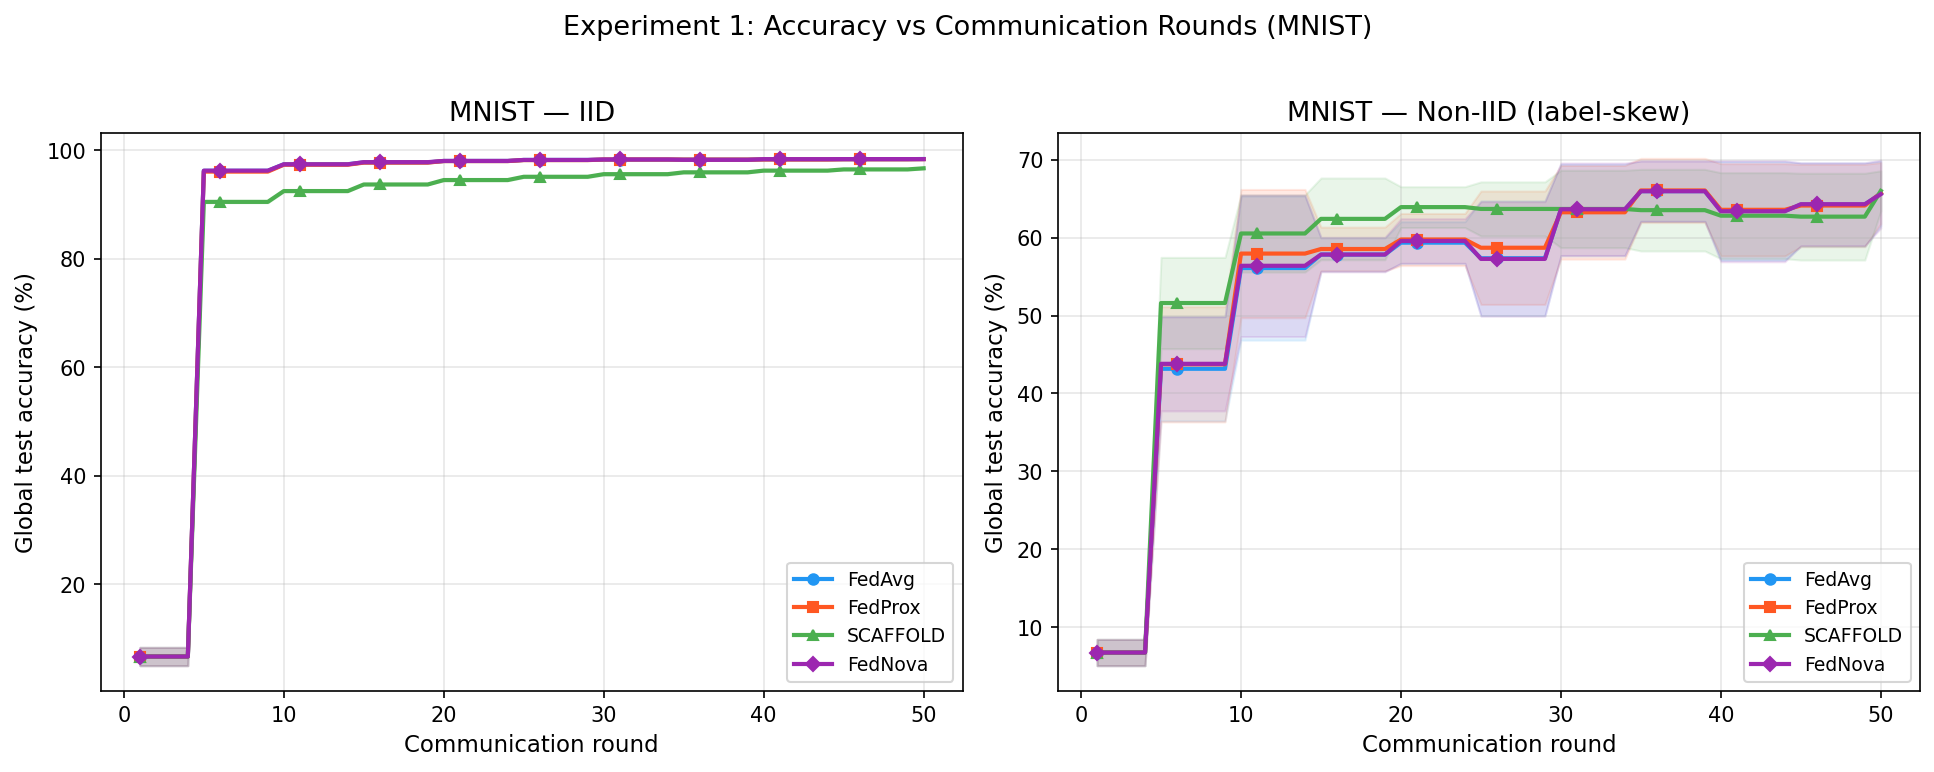

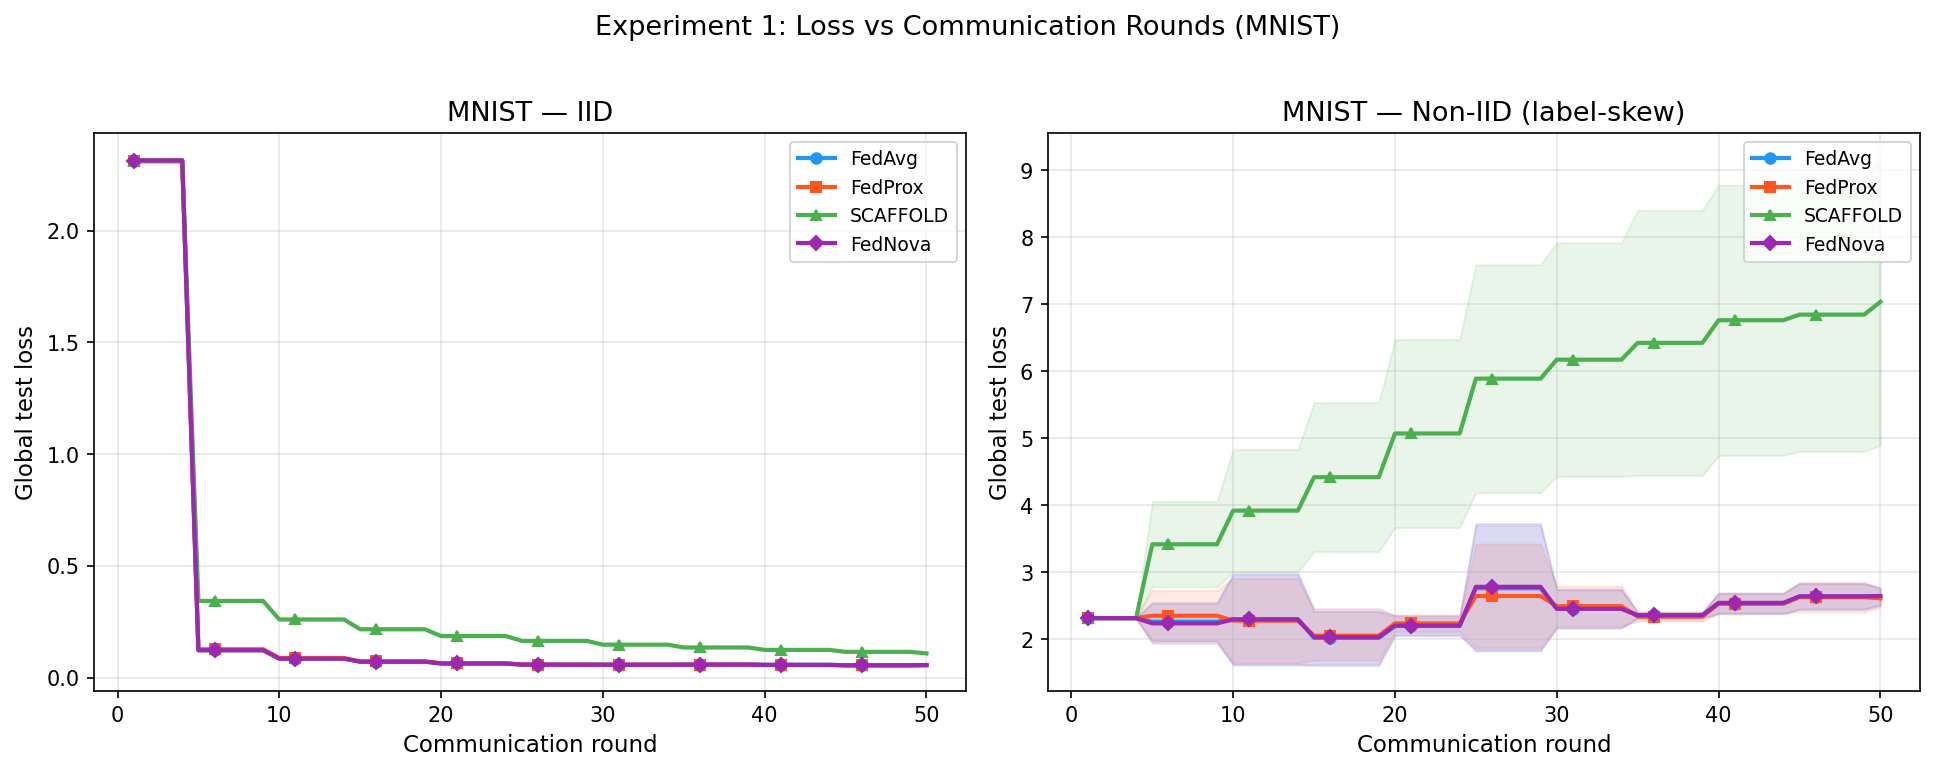


  Final-round performance — MNIST
Algorithm         Distribution Accuracy (%)            Loss
   FedAvg                  IID 98.35 ± 0.12 0.0559 ± 0.0025
  FedNova                  IID 98.34 ± 0.12 0.0565 ± 0.0019
  FedProx                  IID 98.33 ± 0.07 0.0554 ± 0.0014
 SCAFFOLD                  IID 96.64 ± 0.17 0.1082 ± 0.0025
   FedAvg Non-IID (label-skew) 65.69 ± 4.16 2.6306 ± 0.1307
  FedNova Non-IID (label-skew) 65.60 ± 4.38 2.6438 ± 0.1309
  FedProx Non-IID (label-skew) 65.73 ± 3.94 2.6093 ± 0.1342
 SCAFFOLD Non-IID (label-skew) 66.02 ± 2.58 7.0325 ± 2.1419


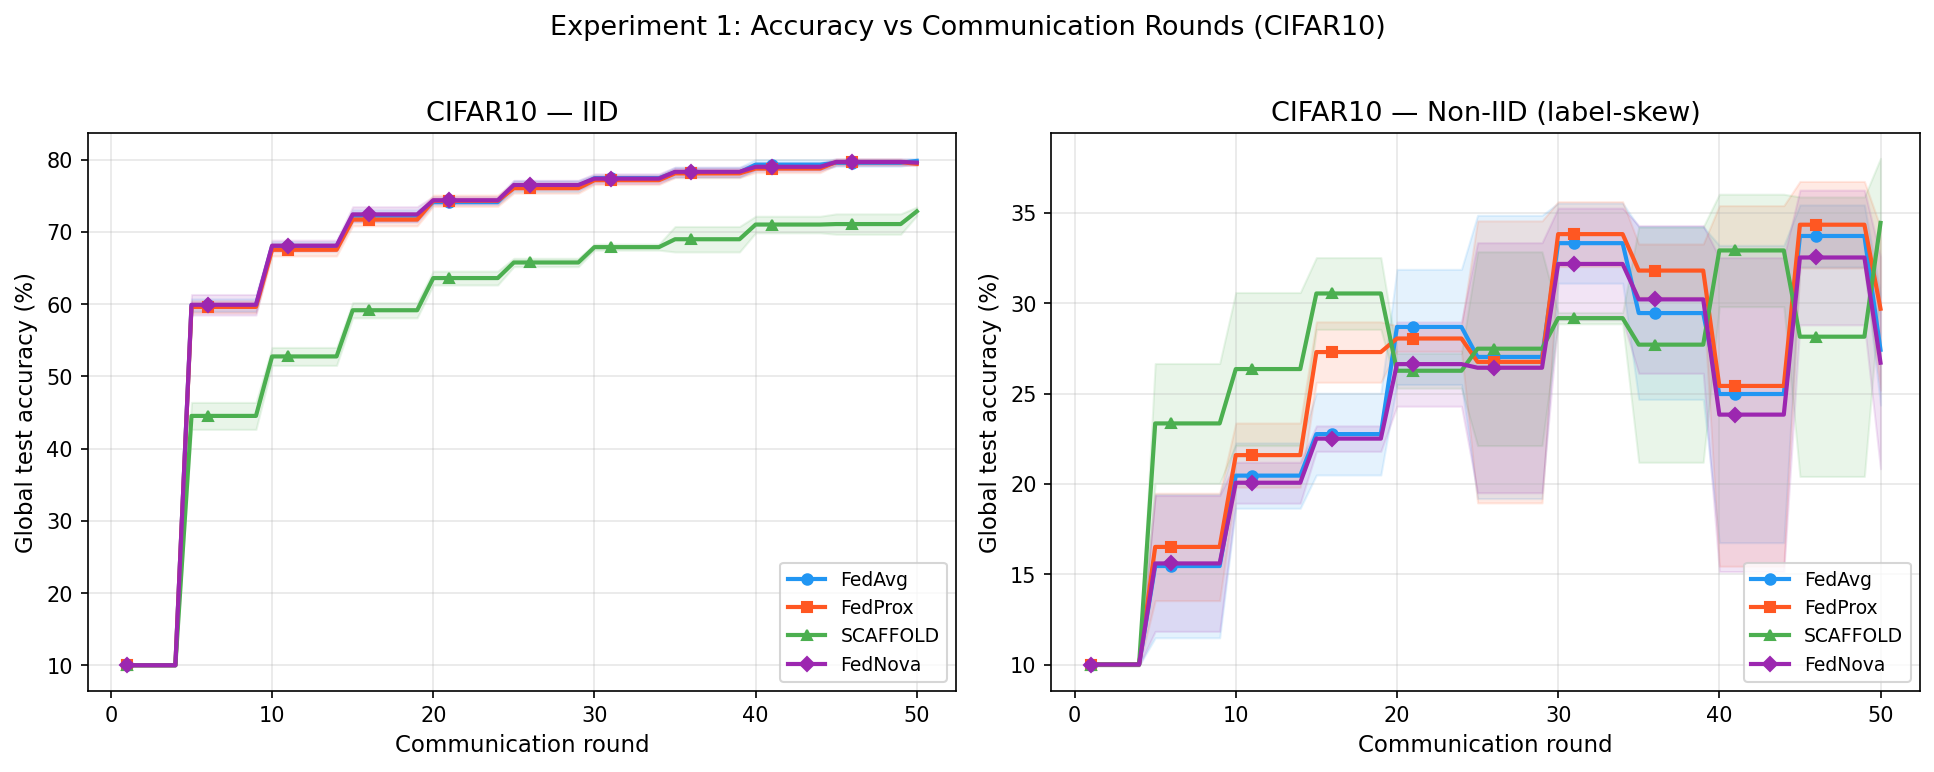

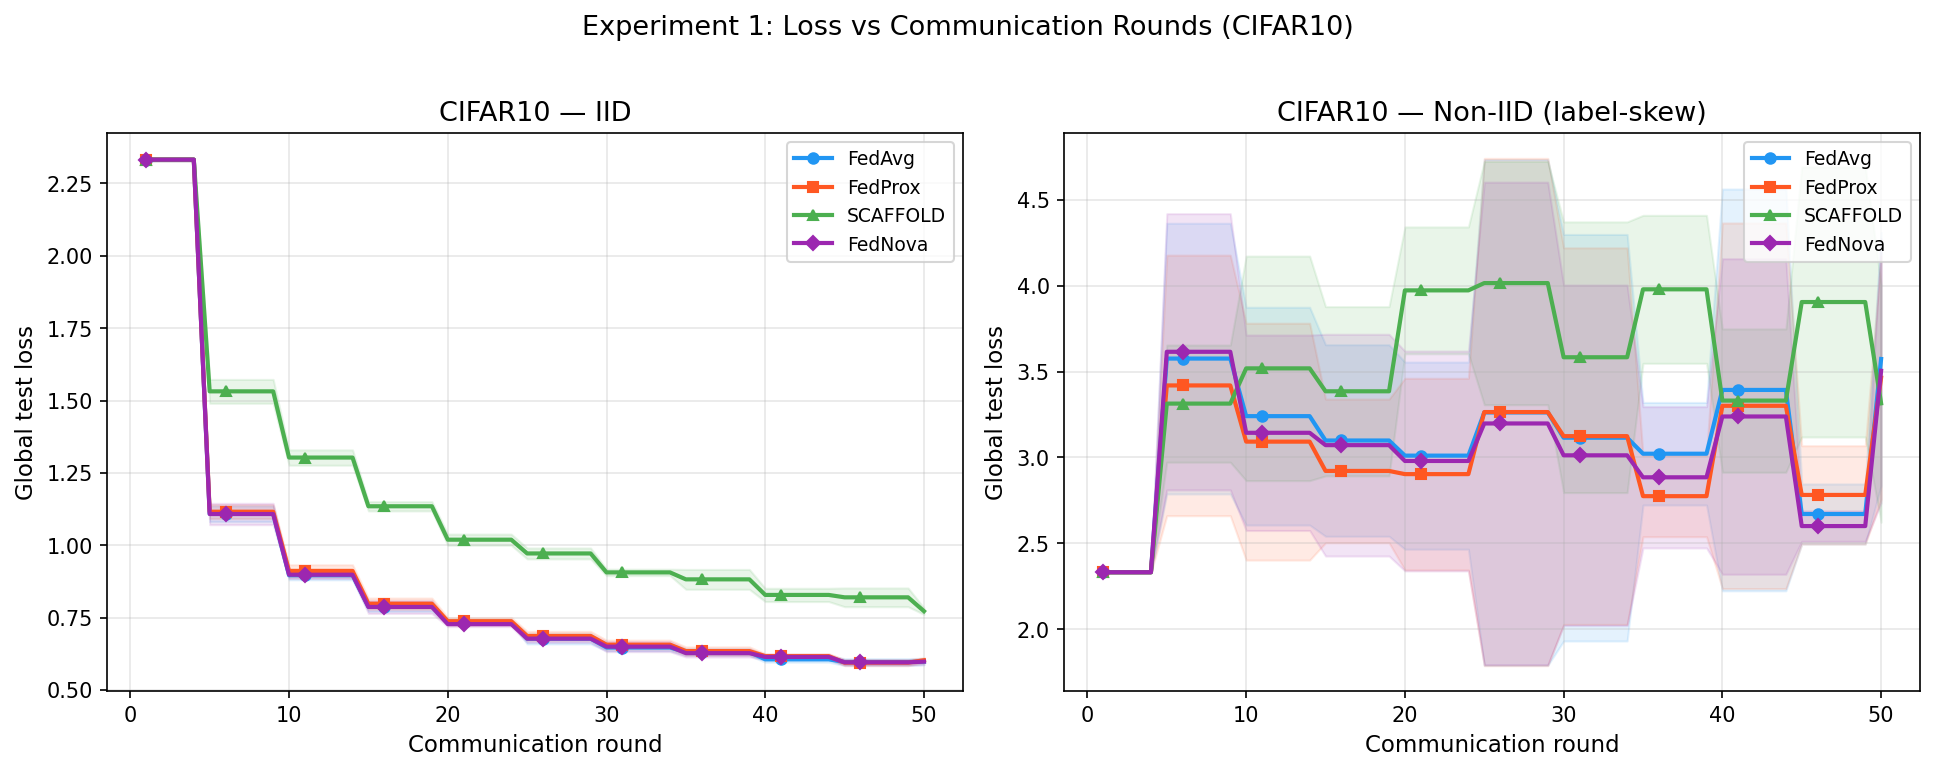


  Final-round performance — CIFAR-10
Algorithm         Distribution Accuracy (%)            Loss
   FedAvg                  IID 79.81 ± 0.35 0.5982 ± 0.0111
  FedNova                  IID 79.58 ± 0.41 0.5980 ± 0.0106
  FedProx                  IID 79.41 ± 0.19 0.6028 ± 0.0082
 SCAFFOLD                  IID 72.83 ± 0.60 0.7722 ± 0.0111
   FedAvg Non-IID (label-skew) 27.42 ± 3.06 3.5730 ± 0.7368
  FedNova Non-IID (label-skew) 26.71 ± 5.86 3.5043 ± 0.7690
  FedProx Non-IID (label-skew) 29.69 ± 4.50 3.4644 ± 0.7078
 SCAFFOLD Non-IID (label-skew) 34.44 ± 3.57 3.3149 ± 0.6917


In [9]:
# ─── Experiment 1 · Plots & Tables ───────────────────────────

def plot_accuracy_curves(agg_df: pd.DataFrame, dataset_name: str, save_name: str):
    split_labels = {
        "iid": "IID",
        "label_skew": "Non-IID (label-skew)"
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

    for ax, split in zip(axes, ["iid", "label_skew"]):
        split_df = agg_df[agg_df["split_type"] == split].copy()

        for algo in CFG.algorithms:
            algo_df = split_df[split_df["algorithm"] == algo].sort_values("round")
            if algo_df.empty:
                continue

            mean_acc = algo_df["test_accuracy_mean"].to_numpy()
            std_acc = algo_df["test_accuracy_std"].fillna(0).to_numpy()
            rounds = algo_df["round"].to_numpy()

            ax.plot(
                rounds,
                mean_acc,
                color=ALGO_COLORS[algo],
                marker=ALGO_MARKERS[algo],
                markevery=max(1, len(rounds) // 10),
                label=algo
            )

            ax.fill_between(
                rounds,
                mean_acc - std_acc,
                mean_acc + std_acc,
                color=ALGO_COLORS[algo],
                alpha=0.12
            )

        ax.set_title(f"{dataset_name.upper()} — {split_labels.get(split, split)}")
        ax.set_xlabel("Communication round")
        ax.set_ylabel("Global test accuracy (%)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="lower right")

    plt.suptitle(f"Experiment 1: Accuracy vs Communication Rounds ({dataset_name.upper()})",
                 fontsize=13, y=1.02)
    plt.tight_layout()

    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_loss_curves(agg_df: pd.DataFrame, dataset_name: str, save_name: str):
    split_labels = {
        "iid": "IID",
        "label_skew": "Non-IID (label-skew)"
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

    for ax, split in zip(axes, ["iid", "label_skew"]):
        split_df = agg_df[agg_df["split_type"] == split].copy()

        for algo in CFG.algorithms:
            algo_df = split_df[split_df["algorithm"] == algo].sort_values("round")
            if algo_df.empty:
                continue

            mean_loss = algo_df["test_loss_mean"].to_numpy()
            std_loss = algo_df["test_loss_std"].fillna(0).to_numpy()
            rounds = algo_df["round"].to_numpy()

            ax.plot(
                rounds,
                mean_loss,
                color=ALGO_COLORS[algo],
                marker=ALGO_MARKERS[algo],
                markevery=max(1, len(rounds) // 10),
                label=algo
            )

            ax.fill_between(
                rounds,
                mean_loss - std_loss,
                mean_loss + std_loss,
                color=ALGO_COLORS[algo],
                alpha=0.12
            )

        ax.set_title(f"{dataset_name.upper()} — {split_labels.get(split, split)}")
        ax.set_xlabel("Communication round")
        ax.set_ylabel("Global test loss")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

    plt.suptitle(f"Experiment 1: Loss vs Communication Rounds ({dataset_name.upper()})",
                 fontsize=13, y=1.02)
    plt.tight_layout()

    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def build_final_table(raw_df: pd.DataFrame, label: str = "") -> pd.DataFrame:
    final_round = raw_df["round"].max()
    final_df = raw_df[raw_df["round"] == final_round].copy()

    table = (
        final_df.groupby(["algorithm", "split_type"])
        .agg(
            accuracy_mean=("test_accuracy", "mean"),
            accuracy_std=("test_accuracy", "std"),
            loss_mean=("test_loss", "mean"),
            loss_std=("test_loss", "std"),
        )
        .reset_index()
    )

    table["accuracy_std"] = table["accuracy_std"].fillna(0.0)
    table["loss_std"] = table["loss_std"].fillna(0.0)

    table["Accuracy (%)"] = (
        table["accuracy_mean"].map("{:.2f}".format)
        + " ± "
        + table["accuracy_std"].map("{:.2f}".format)
    )

    table["Loss"] = (
        table["loss_mean"].map("{:.4f}".format)
        + " ± "
        + table["loss_std"].map("{:.4f}".format)
    )

    table["Distribution"] = table["split_type"].map({
        "iid": "IID",
        "label_skew": "Non-IID (label-skew)"
    }).fillna(table["split_type"])

    table = table.rename(columns={"algorithm": "Algorithm"})
    table = table.sort_values(["Distribution", "Algorithm"]).reset_index(drop=True)

    print(f"\n{'=' * 72}")
    print(f"  Final-round performance — {label}")
    print(f"{'=' * 72}")
    print(table[["Algorithm", "Distribution", "Accuracy (%)", "Loss"]].to_string(index=False))

    out_name = f"final_table_{label.lower().replace('-', '_').replace(' ', '_')}.csv"
    table.to_csv(TABLES_DIR / out_name, index=False)

    return table


# ── MNIST plots and table ───────────────────────────
plot_accuracy_curves(agg_e1_mnist, "mnist", "exp1_mnist_accuracy.png")
plot_loss_curves(agg_e1_mnist, "mnist", "exp1_mnist_loss.png")
final_table_mnist = build_final_table(raw_e1_mnist, "MNIST")

# ── CIFAR-10 plots and table ────────────────────────
if agg_e1_cifar is not None and raw_e1_cifar is not None:
    plot_accuracy_curves(agg_e1_cifar, "cifar10", "exp1_cifar_accuracy.png")
    plot_loss_curves(agg_e1_cifar, "cifar10", "exp1_cifar_loss.png")
    final_table_cifar = build_final_table(raw_e1_cifar, "CIFAR-10")

---
## Section 9 — Experiment 2: Dirichlet α Sweep

**Research question:** How does the *degree* of heterogeneity affect convergence?

Setup: MNIST | 4 algorithms × α ∈ {0.1, 0.5, 1.0} × 3 seeds × 50 rounds


In [10]:
# ═══════════════════════════════════════════════════
# Section 9 · Experiment 2 — Dirichlet α
# ═══════════════════════════════════════════════════

def run_exp2(cfg: FLConfig, dataset_name: str = "mnist") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Experiment 2:
    Study the effect of Dirichlet alpha on federated learning performance.
    Lower alpha => stronger heterogeneity
    Higher alpha => more balanced client distributions
    """
    dataset_name = dataset_name.lower().strip()

    if dataset_name == "mnist":
        train_ds, test_ds, n_cls = train_mnist, test_mnist, N_CLS_MNIST
    elif dataset_name == "cifar10":
        train_ds, test_ds, n_cls = train_cifar, test_cifar, N_CLS_CIFAR
    else:
        raise ValueError(f"Unknown dataset '{dataset_name}'")

    runs = []

    for alpha in cfg.alpha_values:
        for algo in cfg.algorithms:
            for seed in cfg.seeds:
                logger.info(
                    f"Exp2 | dataset={dataset_name} | alpha={alpha} | "
                    f"algo={algo} | seed={seed}"
                )

                client_data = build_client_datasets(
                    dataset=train_ds,
                    split_type="dirichlet",
                    num_clients=cfg.num_clients,
                    n_cls=n_cls,
                    seed=seed,
                    dirichlet_alpha=alpha
                )

                run_df = FederatedServer(algo, cfg, dataset_name).run(
                    train_data=train_ds,
                    test_data=test_ds,
                    client_data=client_data,
                    n_cls=n_cls,
                    split_type="dirichlet",
                    seed=seed,
                    dirichlet_alpha=alpha,
                    labels_per_client=0,
                    mu_tested=cfg.mu if algo == "FedProx" else 0.0,
                    epochs_tested=cfg.local_epochs,
                    verbose=True
                )

                runs.append(run_df)

    return aggregate_runs(runs)


print("Running Experiment 2 — Dirichlet alpha sweep")
raw_e2, agg_e2 = run_exp2(CFG, dataset_name="mnist")

raw_e2.to_csv(RESULTS_DIR / "exp2_dirichlet_raw.csv", index=False)
agg_e2.to_csv(TABLES_DIR / "exp2_dirichlet_aggregated.csv", index=False)

print("Experiment 2 complete.")

23:53:00 [INFO] Exp2 | dataset=mnist | alpha=0.1 | algo=FedAvg | seed=42


Running Experiment 2 — Dirichlet alpha sweep


23:53:04 [INFO] [FedAvg   | dirichlet  | seed=42] round=  1/50 acc=  5.30% loss=2.3041 time=2.96s
23:53:25 [INFO] [FedAvg   | dirichlet  | seed=42] round= 10/50 acc= 84.53% loss=0.4692 time=1.04s
23:53:48 [INFO] [FedAvg   | dirichlet  | seed=42] round= 20/50 acc= 93.32% loss=0.2175 time=3.36s
23:54:11 [INFO] [FedAvg   | dirichlet  | seed=42] round= 30/50 acc= 89.65% loss=0.3336 time=2.45s
23:54:31 [INFO] [FedAvg   | dirichlet  | seed=42] round= 40/50 acc= 91.38% loss=0.2730 time=2.16s
23:55:00 [INFO] [FedAvg   | dirichlet  | seed=42] round= 50/50 acc= 97.12% loss=0.0965 time=3.73s
23:55:00 [INFO] Exp2 | dataset=mnist | alpha=0.1 | algo=FedAvg | seed=52
23:55:03 [INFO] [FedAvg   | dirichlet  | seed=52] round=  1/50 acc=  6.30% loss=2.3232 time=2.92s
23:55:26 [INFO] [FedAvg   | dirichlet  | seed=52] round= 10/50 acc= 90.80% loss=0.2824 time=2.98s
23:55:50 [INFO] [FedAvg   | dirichlet  | seed=52] round= 20/50 acc= 95.37% loss=0.1530 time=2.25s
23:56:12 [INFO] [FedAvg   | dirichlet  | seed

Experiment 2 complete.


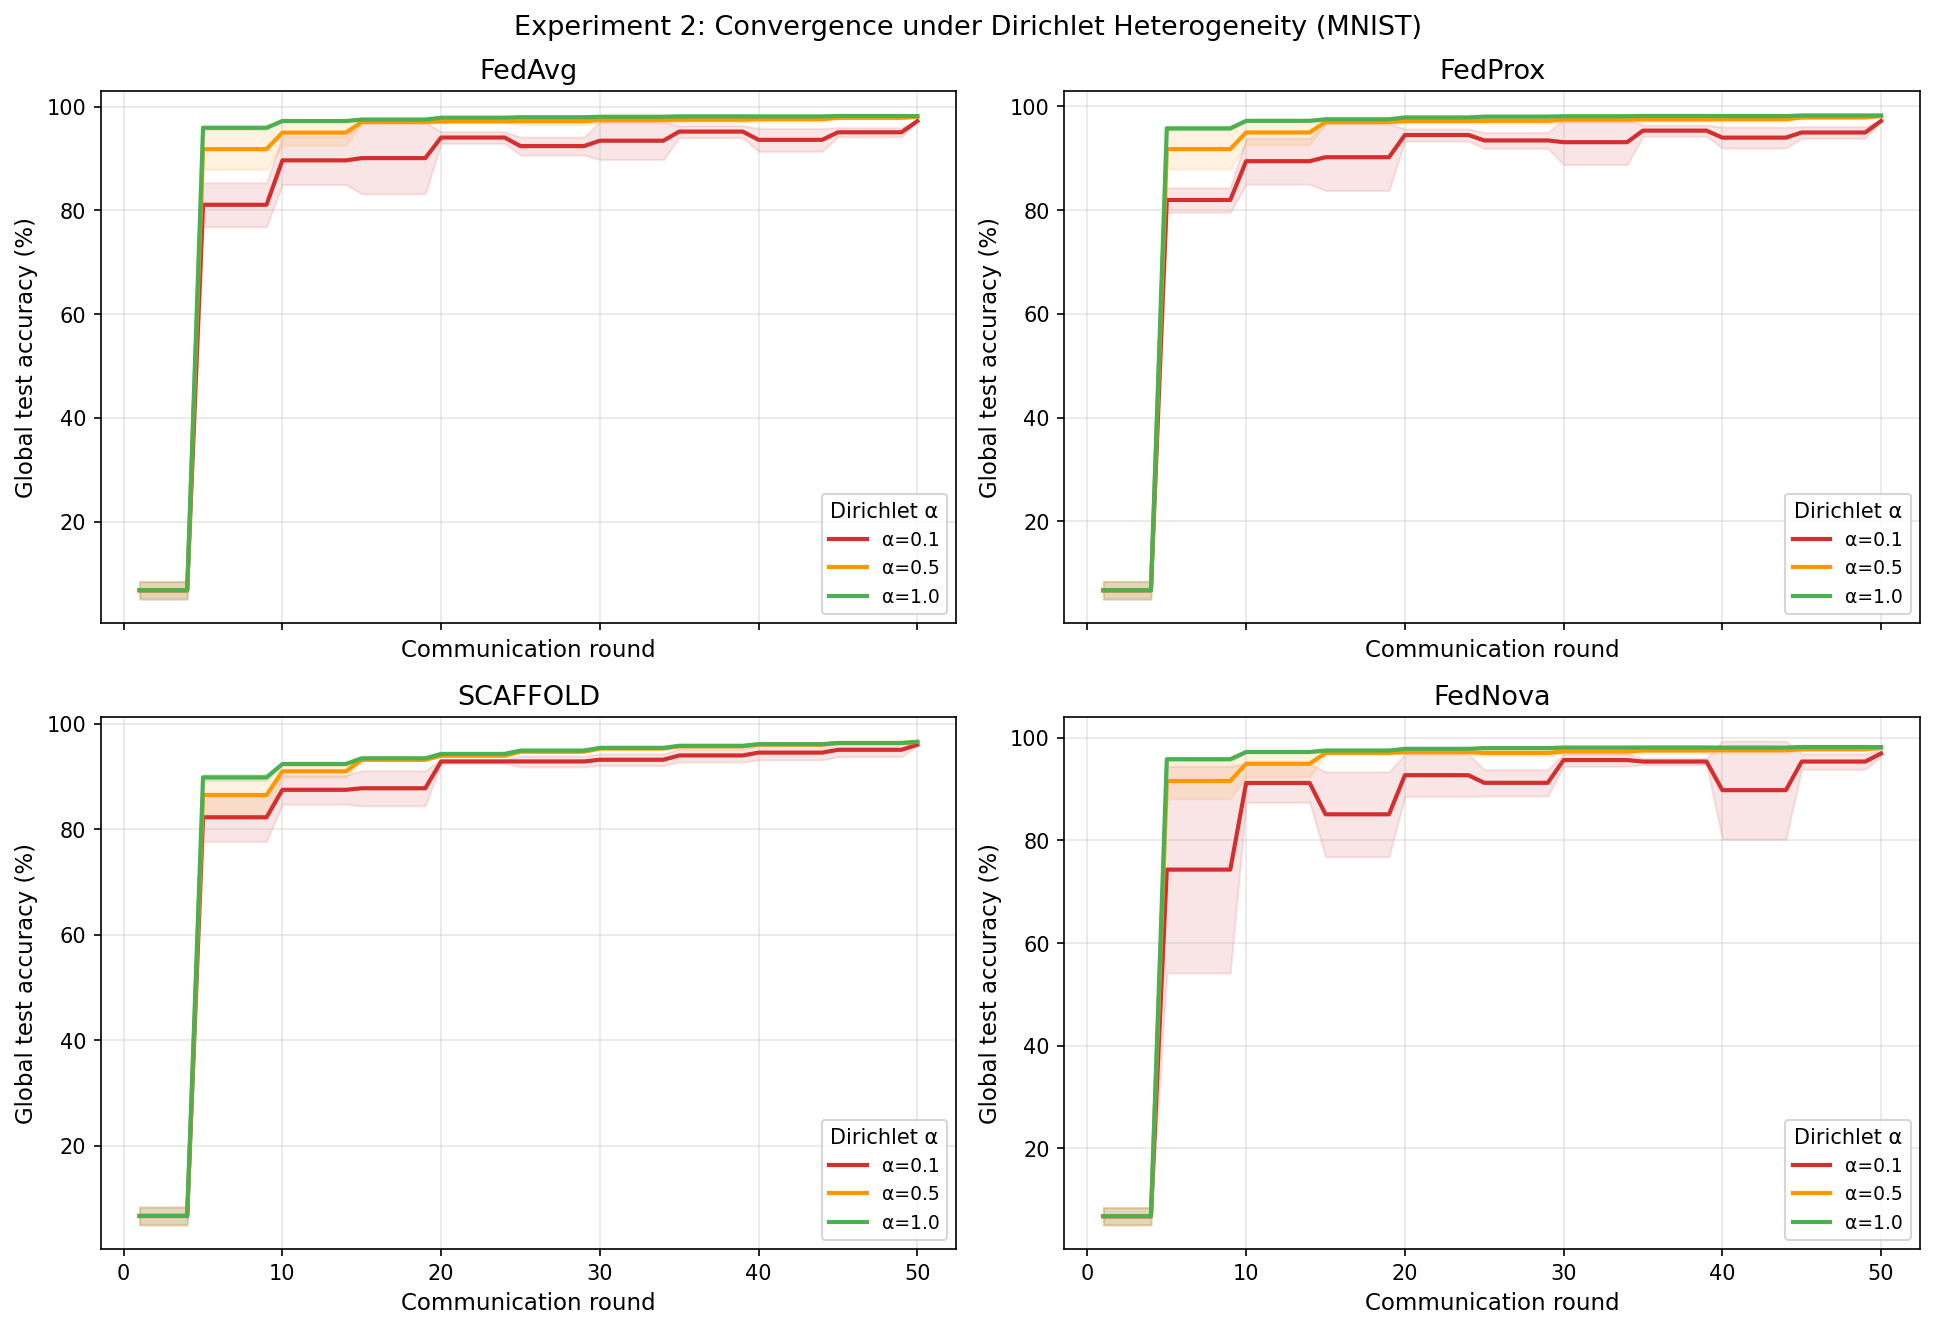

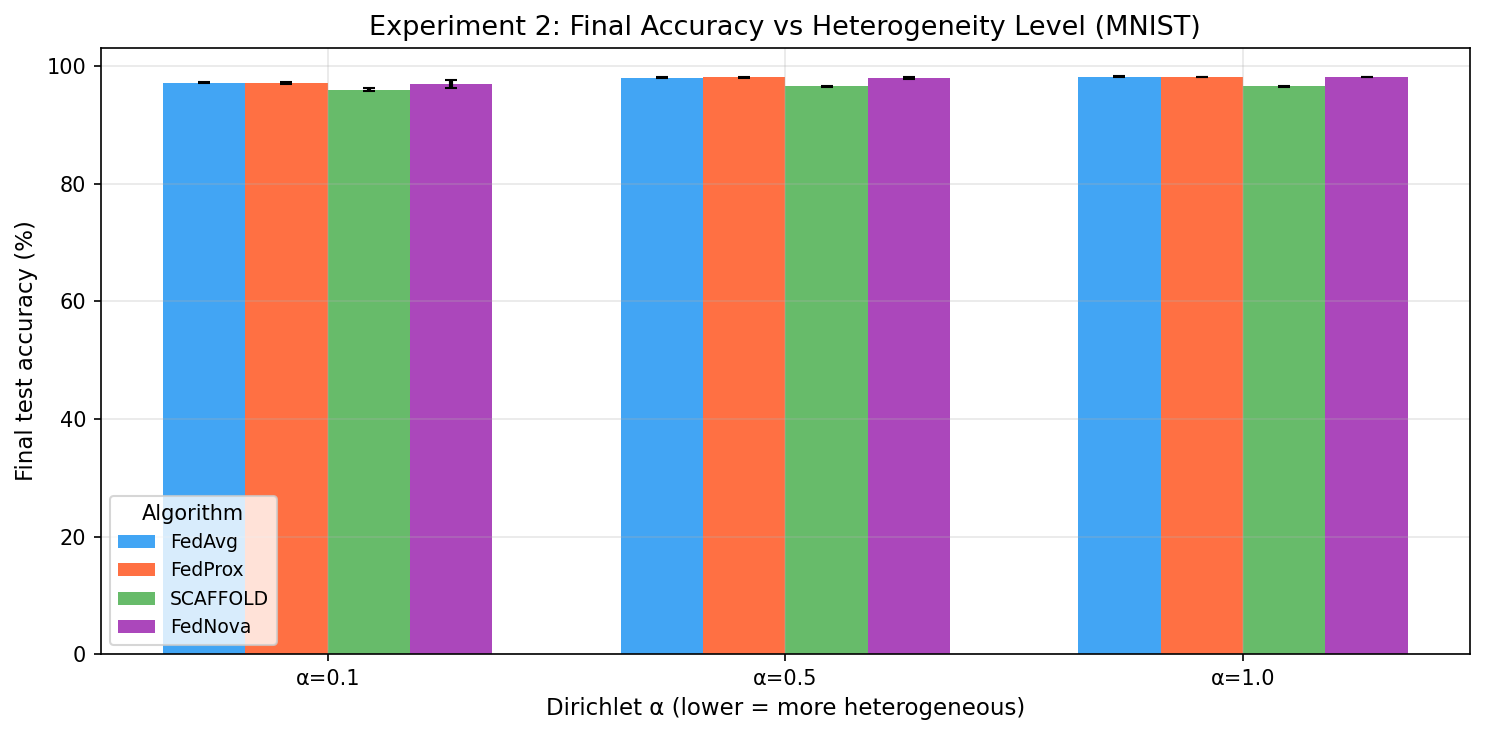


Final accuracy per algorithm × Dirichlet α:
dirichlet_alpha    0.1    0.5    1.0
algorithm                           
FedAvg           97.25  98.08  98.22
FedNova          96.97  98.07  98.21
FedProx          97.18  98.12  98.23
SCAFFOLD         96.04  96.58  96.58


In [11]:
# ─── Experiment 2 · Plots & Table ─────────────────────────────

alpha_palette = {
    0.1: "#D32F2F",
    0.5: "#FF9800",
    1.0: "#4CAF50",
}


def plot_dirichlet_convergence(raw_df: pd.DataFrame, dataset_name: str = "MNIST"):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

    for ax, algo in zip(axes.flat, CFG.algorithms):
        algo_df = raw_df[raw_df["algorithm"] == algo].copy()

        for alpha in sorted(algo_df["dirichlet_alpha"].unique()):
            alpha_df = algo_df[algo_df["dirichlet_alpha"] == alpha].copy()

            grouped = (
                alpha_df.groupby("round")["test_accuracy"]
                .agg(["mean", "std"])
                .reset_index()
                .sort_values("round")
            )

            rounds = grouped["round"].to_numpy()
            means = grouped["mean"].to_numpy()
            stds = grouped["std"].fillna(0).to_numpy()
            color = alpha_palette.get(alpha, "gray")

            ax.plot(
                rounds,
                means,
                color=color,
                label=f"α={alpha}"
            )
            ax.fill_between(
                rounds,
                means - stds,
                means + stds,
                color=color,
                alpha=0.12
            )

        ax.set_title(algo)
        ax.set_xlabel("Communication round")
        ax.set_ylabel("Global test accuracy (%)")
        ax.grid(True, alpha=0.3)
        ax.legend(title="Dirichlet α")

    plt.suptitle(
        f"Experiment 2: Convergence under Dirichlet Heterogeneity ({dataset_name})",
        fontsize=13
    )
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "exp2_dirichlet_curves.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_dirichlet_final_bar(raw_df: pd.DataFrame, dataset_name: str = "MNIST"):
    final_round = raw_df["round"].max()
    final_df = raw_df[raw_df["round"] == final_round].copy()

    summary = (
        final_df.groupby(["algorithm", "dirichlet_alpha"])["test_accuracy"]
        .agg(["mean", "std"])
        .reset_index()
    )

    alphas = sorted(summary["dirichlet_alpha"].unique())
    x = np.arange(len(alphas))
    width = 0.18

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, algo in enumerate(CFG.algorithms):
        sub = summary[summary["algorithm"] == algo].set_index("dirichlet_alpha")

        means = [sub.loc[a, "mean"] if a in sub.index else 0.0 for a in alphas]
        stds = [sub.loc[a, "std"] if a in sub.index else 0.0 for a in alphas]
        stds = [0.0 if pd.isna(v) else float(v) for v in stds]

        positions = x + (i - len(CFG.algorithms) / 2 + 0.5) * width

        ax.bar(
            positions,
            means,
            width,
            yerr=stds,
            label=algo,
            color=ALGO_COLORS[algo],
            alpha=0.85,
            capsize=3
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"α={a}" for a in alphas])
    ax.set_xlabel("Dirichlet α (lower = more heterogeneous)")
    ax.set_ylabel("Final test accuracy (%)")
    ax.set_title(f"Experiment 2: Final Accuracy vs Heterogeneity Level ({dataset_name})")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Algorithm")

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "exp2_dirichlet_bar.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def build_dirichlet_table(raw_df: pd.DataFrame) -> pd.DataFrame:
    final_round = raw_df["round"].max()
    final_df = raw_df[raw_df["round"] == final_round].copy()

    summary = (
        final_df.groupby(["algorithm", "dirichlet_alpha"])["test_accuracy"]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values(["algorithm", "dirichlet_alpha"])
    )

    summary["std"] = summary["std"].fillna(0.0)
    summary["Accuracy (%)"] = (
        summary["mean"].map("{:.2f}".format)
        + " ± "
        + summary["std"].map("{:.2f}".format)
    )

    pivot_display = summary.pivot(
        index="algorithm",
        columns="dirichlet_alpha",
        values="Accuracy (%)"
    )

    pivot_numeric = final_df.groupby(["algorithm", "dirichlet_alpha"])["test_accuracy"] \
        .mean().unstack().round(2)

    print("\nFinal accuracy per algorithm × Dirichlet α:")
    print(pivot_numeric.to_string())

    pivot_numeric.to_csv(TABLES_DIR / "exp2_dirichlet_table_numeric.csv")
    pivot_display.to_csv(TABLES_DIR / "exp2_dirichlet_table_formatted.csv")

    return summary


plot_dirichlet_convergence(raw_e2, dataset_name="MNIST")
plot_dirichlet_final_bar(raw_e2, dataset_name="MNIST")
dirichlet_summary_table = build_dirichlet_table(raw_e2)

---
## Section 10 — Experiment 3: Hyperparameter Sensitivity

**3a — FedProx µ:** {0.001, 0.01, 0.1} on MNIST Non-IID  
**3b — Local epochs E:** {1, 3, 5} on MNIST Non-IID (FedAvg)


In [12]:
# ═══════════════════════════════════════════════════
# Section 10 · Experiment 3 — Hyperparameter Study
# ═══════════════════════════════════════════════════

def run_exp3a_mu(cfg: FLConfig, dataset_name: str = "mnist") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Experiment 3a:
    FedProx sensitivity to proximal coefficient mu
    under label-skew Non-IID setting.
    """
    dataset_name = dataset_name.lower().strip()

    if dataset_name == "mnist":
        train_ds, test_ds, n_cls = train_mnist, test_mnist, N_CLS_MNIST
    elif dataset_name == "cifar10":
        train_ds, test_ds, n_cls = train_cifar, test_cifar, N_CLS_CIFAR
    else:
        raise ValueError(f"Unknown dataset '{dataset_name}'")

    runs = []

    print("Experiment 3a: FedProx mu sensitivity")

    for mu_val in cfg.mu_values:
        cfg_mu = copy.copy(cfg)
        cfg_mu.mu = mu_val

        for seed in cfg.seeds:
            logger.info(
                f"Exp3a | dataset={dataset_name} | algo=FedProx | mu={mu_val} | seed={seed}"
            )

            client_data = build_client_datasets(
                dataset=train_ds,
                split_type="label_skew",
                num_clients=cfg.num_clients,
                n_cls=n_cls,
                seed=seed,
                labels_per_client=cfg.labels_per_client
            )

            run_df = FederatedServer("FedProx", cfg_mu, dataset_name).run(
                train_data=train_ds,
                test_data=test_ds,
                client_data=client_data,
                n_cls=n_cls,
                split_type="label_skew",
                seed=seed,
                labels_per_client=cfg.labels_per_client,
                dirichlet_alpha=0.0,
                mu_tested=mu_val,
                epochs_tested=cfg.local_epochs,
                verbose=True
            )

            runs.append(run_df)

    raw_df, agg_df = aggregate_runs(runs)
    raw_df.to_csv(RESULTS_DIR / "exp3a_mu_raw.csv", index=False)
    agg_df.to_csv(TABLES_DIR / "exp3a_mu_aggregated.csv", index=False)

    print("Experiment 3a complete.\n")
    return raw_df, agg_df


def run_exp3b_epochs(cfg: FLConfig, dataset_name: str = "mnist") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Experiment 3b:
    Sensitivity to number of local epochs
    under label-skew Non-IID setting.
    """
    dataset_name = dataset_name.lower().strip()

    if dataset_name == "mnist":
        train_ds, test_ds, n_cls = train_mnist, test_mnist, N_CLS_MNIST
    elif dataset_name == "cifar10":
        train_ds, test_ds, n_cls = train_cifar, test_cifar, N_CLS_CIFAR
    else:
        raise ValueError(f"Unknown dataset '{dataset_name}'")

    runs = []

    print("Experiment 3b: Local epoch sensitivity")

    for ep in cfg.epoch_values:
        cfg_ep = copy.copy(cfg)
        cfg_ep.local_epochs = ep

        for seed in cfg.seeds:
            logger.info(
                f"Exp3b | dataset={dataset_name} | algo=FedAvg | epochs={ep} | seed={seed}"
            )

            client_data = build_client_datasets(
                dataset=train_ds,
                split_type="label_skew",
                num_clients=cfg.num_clients,
                n_cls=n_cls,
                seed=seed,
                labels_per_client=cfg.labels_per_client
            )

            run_df = FederatedServer("FedAvg", cfg_ep, dataset_name).run(
                train_data=train_ds,
                test_data=test_ds,
                client_data=client_data,
                n_cls=n_cls,
                split_type="label_skew",
                seed=seed,
                labels_per_client=cfg.labels_per_client,
                dirichlet_alpha=0.0,
                mu_tested=0.0,
                epochs_tested=ep,
                verbose=True
            )

            runs.append(run_df)

    raw_df, agg_df = aggregate_runs(runs)
    raw_df.to_csv(RESULTS_DIR / "exp3b_epochs_raw.csv", index=False)
    agg_df.to_csv(TABLES_DIR / "exp3b_epochs_aggregated.csv", index=False)

    print("Experiment 3b complete.\n")
    return raw_df, agg_df


# ── Run Experiment 3 ────────────────────────────────
df_mu, agg_mu = run_exp3a_mu(CFG, dataset_name="mnist")
df_ep, agg_ep = run_exp3b_epochs(CFG, dataset_name="mnist")

01:09:29 [INFO] Exp3a | dataset=mnist | algo=FedProx | mu=0.001 | seed=42


Experiment 3a: FedProx mu sensitivity


01:09:32 [INFO] [FedProx  | label_skew | seed=42] round=  1/50 acc=  5.30% loss=2.3041 time=3.08s
01:09:59 [INFO] [FedProx  | label_skew | seed=42] round= 10/50 acc= 45.84% loss=3.0895 time=3.10s
01:10:29 [INFO] [FedProx  | label_skew | seed=42] round= 20/50 acc= 56.29% loss=2.3021 time=3.51s
01:11:01 [INFO] [FedProx  | label_skew | seed=42] round= 30/50 acc= 57.29% loss=2.7774 time=3.52s
01:11:30 [INFO] [FedProx  | label_skew | seed=42] round= 40/50 acc= 57.05% loss=2.5543 time=3.05s
01:12:04 [INFO] [FedProx  | label_skew | seed=42] round= 50/50 acc= 61.36% loss=2.6511 time=3.57s
01:12:04 [INFO] Exp3a | dataset=mnist | algo=FedProx | mu=0.001 | seed=52
01:12:07 [INFO] [FedProx  | label_skew | seed=52] round=  1/50 acc=  6.30% loss=2.3232 time=2.93s
01:12:36 [INFO] [FedProx  | label_skew | seed=52] round= 10/50 acc= 60.73% loss=2.0039 time=3.72s
01:13:07 [INFO] [FedProx  | label_skew | seed=52] round= 20/50 acc= 61.86% loss=2.0361 time=3.33s
01:13:40 [INFO] [FedProx  | label_skew | see

Experiment 3a complete.

Experiment 3b: Local epoch sensitivity


01:31:37 [INFO] [FedAvg   | label_skew | seed=42] round=  1/50 acc=  5.30% loss=2.3041 time=2.63s
01:32:01 [INFO] [FedAvg   | label_skew | seed=42] round= 10/50 acc= 45.47% loss=3.0838 time=2.68s
01:32:24 [INFO] [FedAvg   | label_skew | seed=42] round= 20/50 acc= 56.28% loss=2.2976 time=2.39s
01:32:47 [INFO] [FedAvg   | label_skew | seed=42] round= 30/50 acc= 57.27% loss=2.7718 time=2.77s
01:33:19 [INFO] [FedAvg   | label_skew | seed=42] round= 40/50 acc= 57.07% loss=2.5497 time=3.40s
01:33:45 [INFO] [FedAvg   | label_skew | seed=42] round= 50/50 acc= 61.36% loss=2.6405 time=2.58s
01:33:45 [INFO] Exp3b | dataset=mnist | algo=FedAvg | epochs=1 | seed=52
01:33:48 [INFO] [FedAvg   | label_skew | seed=52] round=  1/50 acc=  6.30% loss=2.3232 time=2.23s
01:34:10 [INFO] [FedAvg   | label_skew | seed=52] round= 10/50 acc= 60.54% loss=2.0073 time=2.58s
01:34:34 [INFO] [FedAvg   | label_skew | seed=52] round= 20/50 acc= 61.22% loss=2.0465 time=2.51s
01:34:57 [INFO] [FedAvg   | label_skew | seed

Experiment 3b complete.



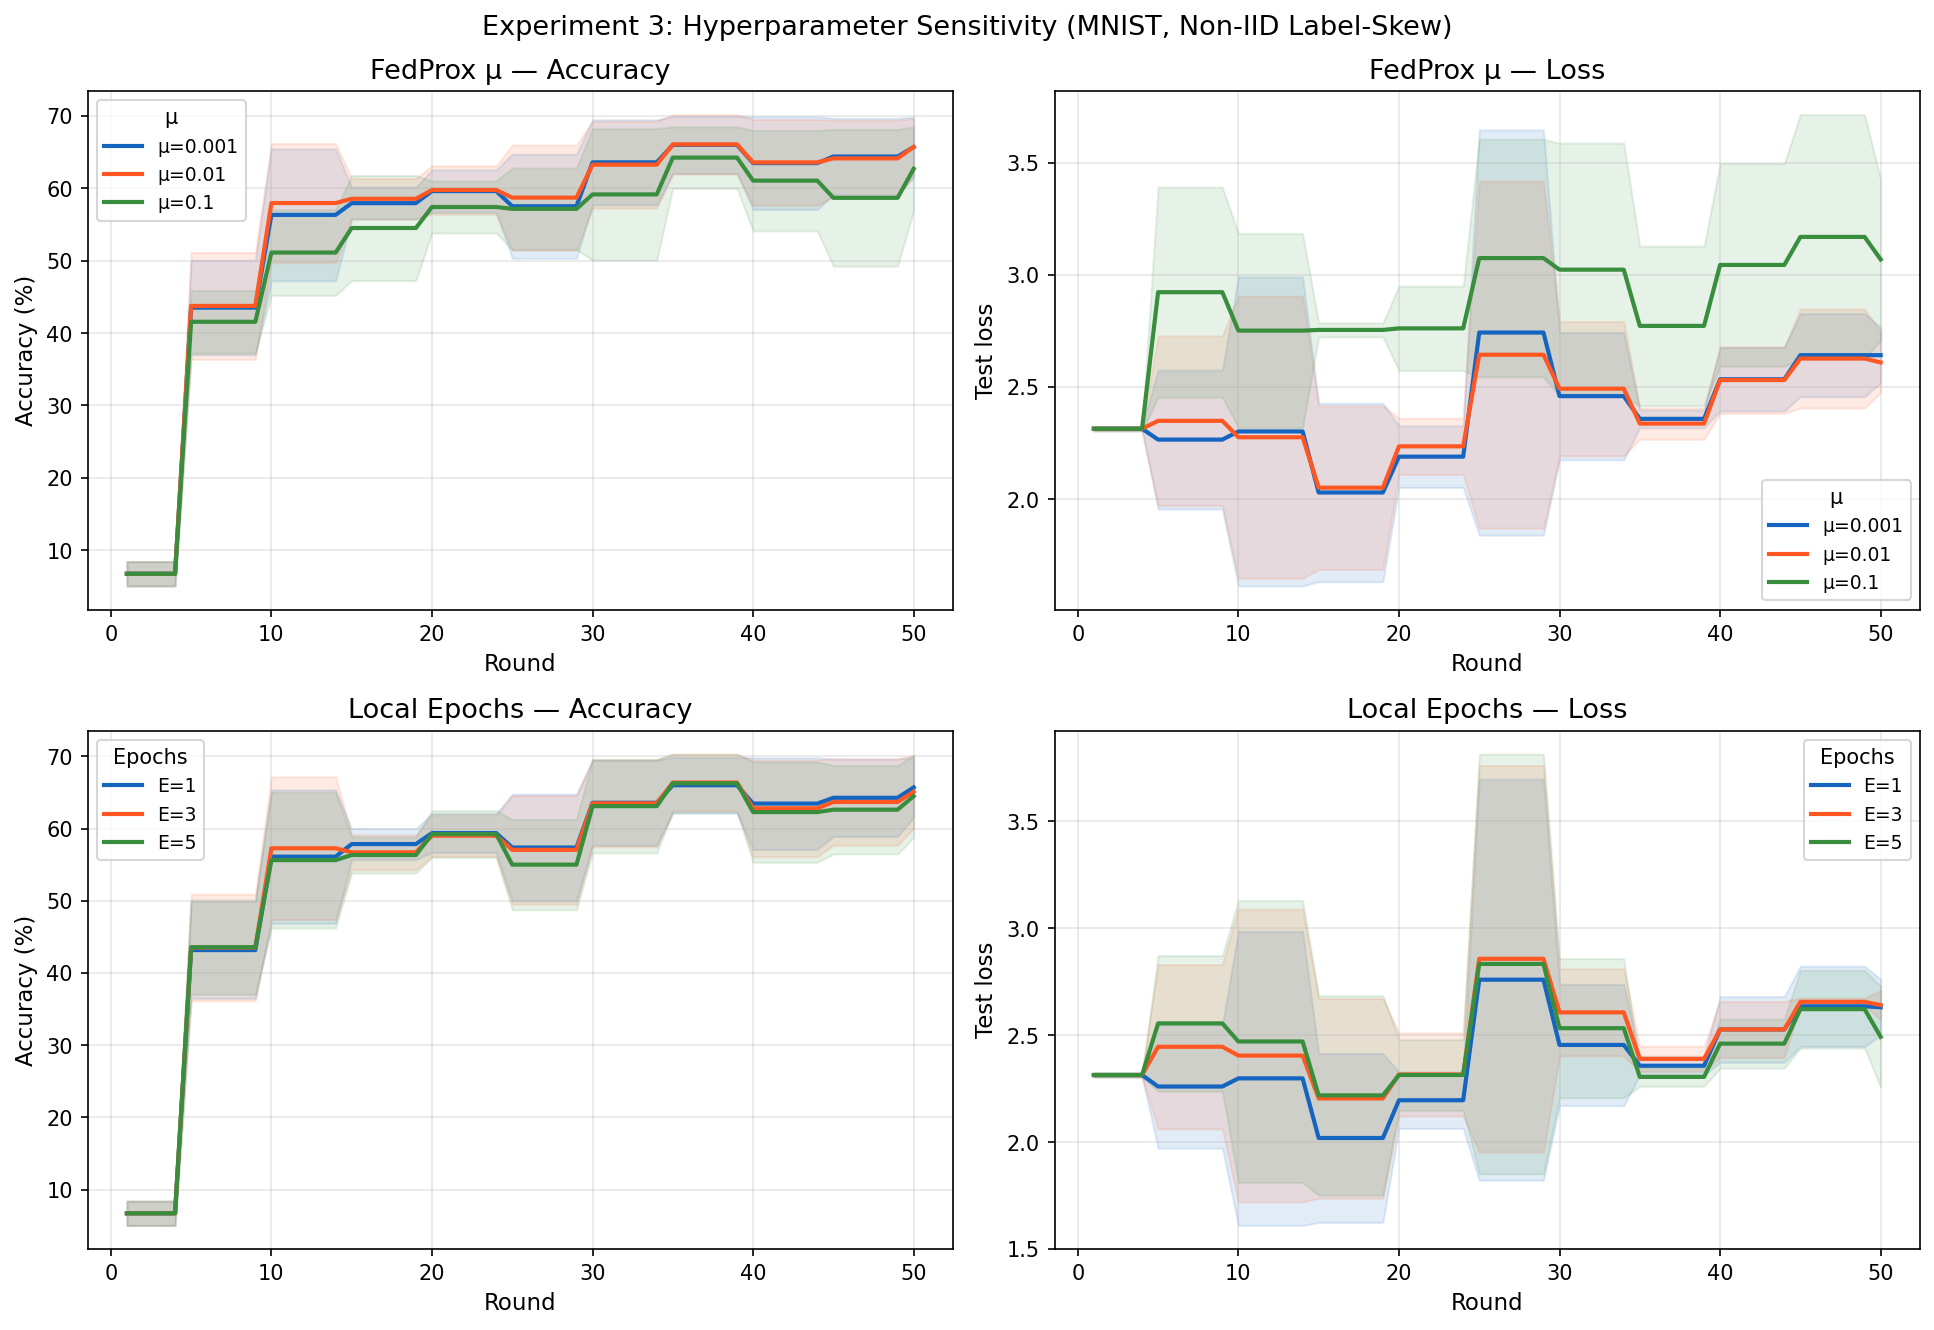


Experiment 3a — Final accuracy by µ:
 mu_tested Accuracy (%)
     0.001 65.70 ± 4.16
     0.010 65.73 ± 3.94
     0.100 62.69 ± 5.80

Experiment 3b — Final accuracy by local epochs:
 epochs_tested Accuracy (%)
             1 65.69 ± 4.16
             3 65.09 ± 5.08
             5 64.48 ± 5.68


In [13]:
# ─── Experiment 3 · Plots & Summary Tables ────────────────────

mu_pal = {
    0.001: "#1565C0",
    0.01: "#FF5722",
    0.1: "#388E3C",
}

ep_pal = {
    1: "#1565C0",
    3: "#FF5722",
    5: "#388E3C",
}


def _plot_mean_std(ax, grouped_df, x_col, mean_col, std_col, label, color,
                   xlabel="Round", ylabel="", title=""):
    grouped_df = grouped_df.sort_values(x_col)

    x = grouped_df[x_col].to_numpy()
    mean = grouped_df[mean_col].to_numpy()
    std = grouped_df[std_col].fillna(0).to_numpy()

    ax.plot(x, mean, color=color, label=label)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)


def plot_exp3_sensitivity(df_mu: pd.DataFrame, df_ep: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # ── FedProx mu sweep ────────────────────────────
    for mu_val in sorted(df_mu["mu_tested"].unique()):
        mu_df = df_mu[df_mu["mu_tested"] == mu_val].copy()

        acc_group = (
            mu_df.groupby("round")["test_accuracy"]
            .agg(["mean", "std"])
            .reset_index()
        )
        loss_group = (
            mu_df.groupby("round")["test_loss"]
            .agg(["mean", "std"])
            .reset_index()
        )

        color = mu_pal.get(mu_val, "gray")

        _plot_mean_std(
            axes[0, 0],
            acc_group,
            x_col="round",
            mean_col="mean",
            std_col="std",
            label=f"µ={mu_val}",
            color=color,
            ylabel="Accuracy (%)",
            title="FedProx µ — Accuracy"
        )

        _plot_mean_std(
            axes[0, 1],
            loss_group,
            x_col="round",
            mean_col="mean",
            std_col="std",
            label=f"µ={mu_val}",
            color=color,
            ylabel="Test loss",
            title="FedProx µ — Loss"
        )

    # ── Local epoch sweep ───────────────────────────
    for ep_val in sorted(df_ep["epochs_tested"].unique()):
        ep_df = df_ep[df_ep["epochs_tested"] == ep_val].copy()

        acc_group = (
            ep_df.groupby("round")["test_accuracy"]
            .agg(["mean", "std"])
            .reset_index()
        )
        loss_group = (
            ep_df.groupby("round")["test_loss"]
            .agg(["mean", "std"])
            .reset_index()
        )

        color = ep_pal.get(ep_val, "gray")

        _plot_mean_std(
            axes[1, 0],
            acc_group,
            x_col="round",
            mean_col="mean",
            std_col="std",
            label=f"E={ep_val}",
            color=color,
            ylabel="Accuracy (%)",
            title="Local Epochs — Accuracy"
        )

        _plot_mean_std(
            axes[1, 1],
            loss_group,
            x_col="round",
            mean_col="mean",
            std_col="std",
            label=f"E={ep_val}",
            color=color,
            ylabel="Test loss",
            title="Local Epochs — Loss"
        )

    axes[0, 0].legend(title="µ")
    axes[0, 1].legend(title="µ")
    axes[1, 0].legend(title="Epochs")
    axes[1, 1].legend(title="Epochs")

    plt.suptitle(
        "Experiment 3: Hyperparameter Sensitivity (MNIST, Non-IID Label-Skew)",
        fontsize=13
    )
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "exp3_sensitivity.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)


def build_exp3_mu_table(df_mu: pd.DataFrame) -> pd.DataFrame:
    final_round = df_mu["round"].max()
    final_df = df_mu[df_mu["round"] == final_round].copy()

    summary = (
        final_df.groupby("mu_tested")["test_accuracy"]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values("mu_tested")
    )

    summary["std"] = summary["std"].fillna(0.0)
    summary["Accuracy (%)"] = (
        summary["mean"].map("{:.2f}".format)
        + " ± "
        + summary["std"].map("{:.2f}".format)
    )

    print("\nExperiment 3a — Final accuracy by µ:")
    print(summary[["mu_tested", "Accuracy (%)"]].to_string(index=False))

    summary.to_csv(TABLES_DIR / "exp3a_mu_table.csv", index=False)
    return summary


def build_exp3_epoch_table(df_ep: pd.DataFrame) -> pd.DataFrame:
    final_round = df_ep["round"].max()
    final_df = df_ep[df_ep["round"] == final_round].copy()

    summary = (
        final_df.groupby("epochs_tested")["test_accuracy"]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values("epochs_tested")
    )

    summary["std"] = summary["std"].fillna(0.0)
    summary["Accuracy (%)"] = (
        summary["mean"].map("{:.2f}".format)
        + " ± "
        + summary["std"].map("{:.2f}".format)
    )

    print("\nExperiment 3b — Final accuracy by local epochs:")
    print(summary[["epochs_tested", "Accuracy (%)"]].to_string(index=False))

    summary.to_csv(TABLES_DIR / "exp3b_epoch_table.csv", index=False)
    return summary


plot_exp3_sensitivity(df_mu, df_ep)
exp3_mu_table = build_exp3_mu_table(df_mu)
exp3_epoch_table = build_exp3_epoch_table(df_ep)

---
## Section 11 — Statistical Significance Testing


  Pairwise Welch t-test — MNIST | label_skew | final round
Algorithm A Algorithm B       Mean A       Mean B  t_stat  p_value  p_bonferroni Significant  Cohens_d     Effect
     FedAvg     FedProx 65.69 ± 4.16 65.73 ± 3.94 -0.0131 0.990174           1.0          No    0.0107 Negligible
     FedAvg    SCAFFOLD 65.69 ± 4.16 66.02 ± 2.58 -0.1167 0.913766           1.0          No    0.0953 Negligible
     FedAvg     FedNova 65.69 ± 4.16 65.60 ± 4.38  0.0248 0.981373           1.0          No    0.0203 Negligible
    FedProx    SCAFFOLD 65.73 ± 3.94 66.02 ± 2.58 -0.1055 0.921833           1.0          No    0.0861 Negligible
    FedProx     FedNova 65.73 ± 3.94 65.60 ± 4.38  0.0382 0.971351           1.0          No    0.0312 Negligible
   SCAFFOLD     FedNova 66.02 ± 2.58 65.60 ± 4.38  0.1419 0.895527           1.0          No    0.1159 Negligible


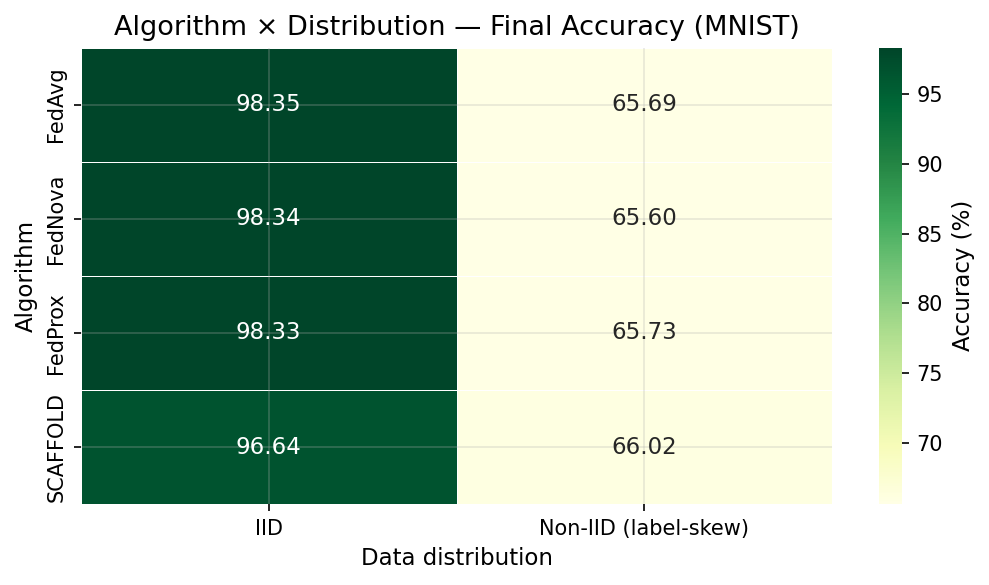

In [14]:
# ═══════════════════════════════════════════════════
# Section 11 · Statistical Tests
# ═══════════════════════════════════════════════════

def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if len(a) < 2 or len(b) < 2:
        return np.nan

    var_a = a.var(ddof=1)
    var_b = b.var(ddof=1)
    pooled = np.sqrt((var_a + var_b) / 2.0)

    if pooled < 1e-12:
        return 0.0

    return abs(a.mean() - b.mean()) / pooled


def effect_size_label(d):
    if pd.isna(d):
        return "N/A"
    if d >= 0.8:
        return "Large"
    if d >= 0.5:
        return "Medium"
    if d >= 0.2:
        return "Small"
    return "Negligible"


def significance_table(raw_df: pd.DataFrame,
                       dataset_name: str = "mnist",
                       split: str = "label_skew") -> pd.DataFrame:
    """
    Pairwise Welch t-tests on final-round test accuracy with Bonferroni correction.
    """
    dataset_name = dataset_name.lower().strip()

    final_round = raw_df["round"].max()
    final_df = raw_df[
        (raw_df["dataset"] == dataset_name) &
        (raw_df["split_type"] == split) &
        (raw_df["round"] == final_round)
    ].copy()

    pairs = list(itertools.combinations(CFG.algorithms, 2))
    rows = []

    for algo_a, algo_b in pairs:
        vals_a = final_df[final_df["algorithm"] == algo_a]["test_accuracy"].to_numpy(dtype=float)
        vals_b = final_df[final_df["algorithm"] == algo_b]["test_accuracy"].to_numpy(dtype=float)

        if len(vals_a) < 2 or len(vals_b) < 2:
            continue

        t_stat, p_val = stats.ttest_ind(vals_a, vals_b, equal_var=False)
        p_bonf = min(p_val * len(pairs), 1.0)
        d_val = cohens_d(vals_a, vals_b)

        rows.append({
            "Algorithm A": algo_a,
            "Algorithm B": algo_b,
            "Mean A": f"{vals_a.mean():.2f} ± {vals_a.std(ddof=1):.2f}",
            "Mean B": f"{vals_b.mean():.2f} ± {vals_b.std(ddof=1):.2f}",
            "t_stat": round(float(t_stat), 4),
            "p_value": round(float(p_val), 6),
            "p_bonferroni": round(float(p_bonf), 6),
            "Significant": "Yes" if p_bonf < 0.05 else "No",
            "Cohens_d": round(float(d_val), 4) if not pd.isna(d_val) else np.nan,
            "Effect": effect_size_label(d_val),
        })

    df_stats = pd.DataFrame(rows)

    print("\n" + "=" * 88)
    print(f"  Pairwise Welch t-test — {dataset_name.upper()} | {split} | final round")
    print("=" * 88)
    if df_stats.empty:
        print("No valid pairwise comparisons available.")
    else:
        print(df_stats.to_string(index=False))

    df_stats.to_csv(TABLES_DIR / f"significance_tests_{dataset_name}_{split}.csv", index=False)
    return df_stats


def plot_algorithm_heatmap(raw_df: pd.DataFrame,
                           dataset_name: str = "mnist",
                           save_name: str = "algorithm_heatmap.png"):
    """
    Heatmap of final-round mean test accuracy by algorithm and data distribution.
    """
    dataset_name = dataset_name.lower().strip()
    final_round = raw_df["round"].max()

    final_df = raw_df[
        (raw_df["dataset"] == dataset_name) &
        (raw_df["round"] == final_round)
    ].copy()

    pivot = (
        final_df.groupby(["algorithm", "split_type"])["test_accuracy"]
        .mean()
        .unstack()
    )

    rename_cols = {
        "iid": "IID",
        "label_skew": "Non-IID (label-skew)",
        "dirichlet": "Dirichlet"
    }
    pivot = pivot.rename(columns=rename_cols)

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="YlGn",
        linewidths=0.4,
        ax=ax,
        cbar_kws={"label": "Accuracy (%)"},
        annot_kws={"size": 11}
    )

    ax.set_title(f"Algorithm × Distribution — Final Accuracy ({dataset_name.upper()})")
    ax.set_xlabel("Data distribution")
    ax.set_ylabel("Algorithm")

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / save_name, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ── Run tests and heatmap ───────────────────────────
sig_df = significance_table(
    raw_e1_mnist,
    dataset_name="mnist",
    split="label_skew"
)

plot_algorithm_heatmap(
    raw_e1_mnist,
    dataset_name="mnist",
    save_name="algorithm_heatmap_mnist.png"
)

---
## Section 12 — Final Summary & Algorithm Guide

In [15]:
# ═══════════════════════════════════════════════════
# Section 12 · Final Summary
# ═══════════════════════════════════════════════════

# ── Rounds to reach target accuracy ─────────────────
def rounds_to_target(raw_df: pd.DataFrame, target: float = 80.0) -> pd.DataFrame:
    rows = []

    for (algo, split, seed), group in raw_df.groupby(
            ["algorithm", "split_type", "seed"]):

        hit = group[group["test_accuracy"] >= target]["round"]

        rows.append({
            "Algorithm": algo,
            "Split": split,
            "Seed": seed,
            "Rounds": int(hit.min()) if len(hit) > 0 else -1
        })

    df = pd.DataFrame(rows)

    agg = df.groupby(["Algorithm", "Split"])["Rounds"].agg(
        Mean=lambda x: x[x > 0].mean() if (x > 0).any() else -1,
        Std=lambda x: x[x > 0].std() if (x > 0).any() else 0,
        Reached=lambda x: f"{(x > 0).sum()}/{len(x)}",
    ).reset_index()

    agg["Rounds (mean±std)"] = agg.apply(
        lambda r: f"{r.Mean:.1f} ± {r.Std:.1f}" if r.Mean > 0 else "Not reached",
        axis=1
    )

    return agg


print("Rounds to reach 80% accuracy (MNIST):")
conv = rounds_to_target(raw_e1_mnist, target=80.0)

print(conv[["Algorithm", "Split", "Rounds (mean±std)", "Reached"]].to_string(index=False))
conv.to_csv(TABLES_DIR / "convergence_rounds.csv", index=False)


# ── Master table across datasets ────────────────────
frames = [raw_e1_mnist.assign(Dataset="MNIST")]

if raw_e1_cifar is not None:
    frames.append(raw_e1_cifar.assign(Dataset="CIFAR-10"))

combined = pd.concat(frames, ignore_index=True)

final_all = combined[combined["round"] == combined["round"].max()].copy()

master = (
    final_all.groupby(["Dataset", "algorithm", "split_type"])["test_accuracy"]
    .agg(Mean="mean", Std="std")
    .reset_index()
)

master["Std"] = master["Std"].fillna(0.0)

master["Accuracy (%)"] = (
    master["Mean"].map("{:.2f}".format)
    + " ± "
    + master["Std"].map("{:.2f}".format)
)

master["Distribution"] = master["split_type"].map({
    "iid": "IID",
    "label_skew": "Non-IID (label-skew)",
    "dirichlet": "Dirichlet"
}).fillna(master["split_type"])

master = master.rename(columns={"algorithm": "Algorithm"})
master = master.sort_values(["Dataset", "Distribution", "Algorithm"]).reset_index(drop=True)

print("\n" + "=" * 70)
print("  MASTER TABLE — Final accuracy (mean ± std, 3 seeds)")
print("=" * 70)
print(master[["Dataset", "Algorithm", "Distribution", "Accuracy (%)"]].to_string(index=False))

master.to_csv(TABLES_DIR / "master_table.csv", index=False)


# ── Save locations ──────────────────────────────────
print(f"\nFigures saved → {FIGURES_DIR.resolve()}")
print(f"Tables saved  → {TABLES_DIR.resolve()}")

Rounds to reach 80% accuracy (MNIST):
Algorithm      Split Rounds (mean±std) Reached
   FedAvg        iid         5.0 ± 0.0     3/3
   FedAvg label_skew       Not reached     0/3
  FedNova        iid         5.0 ± 0.0     3/3
  FedNova label_skew       Not reached     0/3
  FedProx        iid         5.0 ± 0.0     3/3
  FedProx label_skew       Not reached     0/3
 SCAFFOLD        iid         5.0 ± 0.0     3/3
 SCAFFOLD label_skew       Not reached     0/3

  MASTER TABLE — Final accuracy (mean ± std, 3 seeds)
 Dataset Algorithm         Distribution Accuracy (%)
CIFAR-10    FedAvg                  IID 79.81 ± 0.35
CIFAR-10   FedNova                  IID 79.58 ± 0.41
CIFAR-10   FedProx                  IID 79.41 ± 0.19
CIFAR-10  SCAFFOLD                  IID 72.83 ± 0.60
CIFAR-10    FedAvg Non-IID (label-skew) 27.42 ± 3.06
CIFAR-10   FedNova Non-IID (label-skew) 26.71 ± 5.86
CIFAR-10   FedProx Non-IID (label-skew) 29.69 ± 4.50
CIFAR-10  SCAFFOLD Non-IID (label-skew) 34.44 ± 3.57
   MNIS

---
## References

[1] McMahan et al. *Communication-Efficient Learning of Deep Networks from Decentralized Data.* AISTATS 2017.  
[2] Li et al. *Federated Optimization in Heterogeneous Networks (FedProx).* MLSys 2020.  
[3] Karimireddy et al. *SCAFFOLD: Stochastic Controlled Averaging for Federated Learning.* ICML 2020.  
[4] Wang et al. *Tackling the Objective Inconsistency Problem in Heterogeneous Federated Optimization (FedNova).* NeurIPS 2020.  
[5] Kairouz et al. *Advances and Open Problems in Federated Learning.* Foundations and Trends in ML, 2021.
